# Midiendo Asimetrías Materia-Antimateria en el Gran Colisionador de Hadrones

# Introducción
__________

<b> ¡Bienvenidos al primer proyecto guiado del Portal de Datos Abiertos de LHCb - Hackathon Centroamérica! </b>

<div align="justify">Aquí podrás analizar datos tomados por el Gran Colisionador de Hadrones (LHC) en el CERN. El objetivo de este estudio es que puedas buscar diferencias en el comportamiento de la materia y la  <a href="https://en.wikipedia.org/wiki/Antimatter">antimateria</a>. Este proyecto te permitirá realizar tu propio análisis de datos a un nivel similar al de la investigación del CERN. Este proyecto no requiere un conocimiento detallado de la física de partículas. Es más adecuado para personas con una formación científica y matemática equivalente a la requerida para solicitar ingreso a la universidad en una disciplina de ciencias, tecnología, ingeniería o matemáticas. También sería ventajoso tener cierta familiaridad previa con la programación informática. Se proporciona información teórica adicional o conocimientos de programación que puedas necesitar a medida que avanza el proyecto.</div>

Antes de empezar, puede ser útil que aprendas más sobre las asimetrías materia-antimateria, qué esperamos aprender al estudiarlas y cómo podemos detectarlas con experimentos como el experimento LHCb en el CERN.

Aquí hay algunos detalles que se relacionan directamente con este proyecto:

* ¿Cuál es el enfoque de la [física de partículas](Background-Information-Notebooks/ProjectIntro.ipynb) de este experimento? ¿y qué estudiaré en este proyecto?

* ¿Cómo registra los datos el [detector](Background-Information-Notebooks/DetectorSoftwareDataSample.ipynb) LHCb ?

# Empezando

## Objetivos

* Familiarizar con la ayuda disponible para la programación.
* Introducción de los datos de la simulación en el programa.
________________________

<div align="justify">Al igual que los investigadores del CERN, programarás tu propio análisis. Esto utilizará el lenguaje de programación Python. No es necesario tener experiencia previa en programación en Python para seguir este proyecto. Habrá pistas disponibles para ayudarte en el camino. Puedes encontrar útiles estos tutoriales sobre Python:</div>

[Tutoriales de Python](http://www.tutorialspoint.com/python/)

La guía de programación más importante que te proporcionamos está en forma de un análisis no relacionado. Hemos realizado un [análisis de los ganadores del Premio Nobel](Example-Analysis.ipynb). Ese enlace te proporciona el código completo para ello. Las habilidades de programación requeridas para este análisis de los Nobel son muy similares a las necesarias para el análisis de física de partículas. Por lo tanto, al leer y comprender ese análisis, puedes copiar y adaptar las líneas de código para realizar tu análisis de física de partículas.

## Leyendo datos de simulación

Para empezar y comprobar que el primer código que escribirás funciona correctamente, es mejor empezar analizando datos simulados en lugar de datos reales del LHC. Los datos reales contienen no solo el tipo de eventos que deseas analizar, conocidos como 'señal', sino también eventos que pueden falsificarlos, conocidos como 'fondo'. Las mediciones de datos reales también están limitadas por la resolución del detector. Los datos de simulación simplificados proporcionados aquí contienen solo los eventos de señal y proporcionan los resultados que se obtendrían para un detector perfecto.

IMPORTANTE: Para cada recuadro de código que ya tenga código, como el siguiente, debes hacer clic dentro y presionar shift+enter para ejecutar el código.

Si el `In [x]`: a la izquierda de un recuadro de código cambia a `In [*]`:, significa que el código en ese recuadro se está ejecutando actualmente.

In [ ]:
# Importando librerías necesarias
%matplotlib inline
from pathlib import Path
import warnings

import numpy
import os
import uproot
import pandas 
from matplotlib import pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit as cf

warnings.filterwarnings('ignore')
pandas.set_option('display.max_columns', None)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "Data"

print(f"Directorio del proyecto: {BASE_DIR}")
print(f"Directorio de los datos: {DATA_DIR}")

Directorio del proyecto: c:\Users\mario\Documents\LHCb\opendata-project-1.2
Directorio de los datos: c:\Users\mario\Documents\LHCb\opendata-project-1.2\Data


In [2]:
# Verificación de los archivos
data_files = {
    "simulation": DATA_DIR / "PhaseSpaceSimulation.root",
    "magnet_up": DATA_DIR / "B2HHH_MagnetUp.root",
    "magnet_down": DATA_DIR / "B2HHH_MagnetDown.root"
}
for name, path in data_files.items():
    status = "Encontado" if path.exists() else "No encontrado"
    print(f"{name}: {status} - {path}")

simulation: Encontado - c:\Users\mario\Documents\LHCb\opendata-project-1.2\Data\PhaseSpaceSimulation.root
magnet_up: Encontado - c:\Users\mario\Documents\LHCb\opendata-project-1.2\Data\B2HHH_MagnetUp.root
magnet_down: Encontado - c:\Users\mario\Documents\LHCb\opendata-project-1.2\Data\B2HHH_MagnetDown.root


Si necesitas ayuda con la programación, además del [código de ejemplo](Example-Analysis.ipynb), hay algunas pistas dentro de cada sección y una [lista de referencia de funciones](Background-Information-Notebooks/FunctionReferences.pdf).

In [ ]:
# Cargando los datos simulados como un marco de datos
with uproot.open("Data/PhaseSpaceSimulation.root:PhaseSpaceTree") as data:
    sim_data = data.arrays(data.keys(),library="pd")

In [ ]:
# Lectura para la simulación (alternativa)
simulation_path = DATA_DIR / "PhaseSpaceSimulation.root"
with uproot.open(simulation_path) as root_file:
    simulation_tree = root_file["PhaseSpaceTree"]
    sim_data = simulation_tree.arrays(library = "pd")

<div align="justify">Ahora que puedes acceder a los datos, puedes usar varias funciones que te ayudarán a analizarlos. Puedes encontrar estas funciones en las bibliotecas al principio de la página. Intenta hacer una tabla de parte de la información dentro de tu archivo de datos para que puedas hacerte una idea de los valores típicos de los datos en el conjunto. Comprender el rango de valores para diferentes variables te ayudará a trazar gráficos.</div>

Los datos contienen información sobre 'eventos' que se observaron en el detector. Un evento se refiere a las partículas producidas cuando tuvo lugar una interacción al chocar dos protones en el LHC. Los datos que tienes incluyen información sobre partículas observadas en el detector después de cada colisión. Si piensas en los datos como una tabla, cada fila de la tabla son los resultados de una colisión diferente. Las columnas de la tabla son diferentes cantidades medidas sobre las partículas producidas en la colisión.

Nos interesa analizar las desintegraciones de partículas llamadas mesones B<sup>+</sup> o B<sup>-</sup> que se desintegran en otros tres mesones llamados kaones (K<sup>+</sup> o K<sup>-</sup>). Los eventos que se te han dado son aquellos en los que este proceso pudo haber ocurrido. El detector se ha utilizado para reconstruir trayectorias que podrían provenir de los kaones. Se te dan los momentos medidos, la carga y la probabilidad de que las trayectorias sean kaones. Se te da información para tres trayectorias en cada evento, aquellas que podrían ser los tres kaones en los que se desintegró un mesón B<sup>+</sup> o B<sup>-</sup>. La siguiente información está disponible sobre cada evento: [lista de información](Background-Information-Notebooks/EventData.ipynb)

In [ ]:
# Creando una tabla de las variables de datos
sim_data.head()

,B_FlightDistance,B_VertexChi2,H1_PX,H1_PY,H1_PZ,H1_ProbK,H1_ProbPi,H1_Charge,H1_IPChi2,H1_isMuon,H2_PX,H2_PY,H2_PZ,H2_ProbK,H2_ProbPi,H2_Charge,H2_IPChi2,H2_isMuon,H3_PX,H3_PY,H3_PZ,H3_ProbK,H3_ProbPi,H3_Charge,H3_IPChi2,H3_isMuon
0,0.0,1.0,3551.84,1636.96,23904.14,1.0,0.0,-1,1.0,0,41507.15,15980.59,331663.64,1.0,0.0,1,1.0,0,36100.40,16546.83,295600.61,1.0,0.0,-1,1.0,0
1,0.0,1.0,-2525.98,-5284.05,35822.00,1.0,0.0,1,1.0,0,-43182.91,-96553.03,585289.31,1.0,0.0,-1,1.0,0,-8648.32,-16617.56,98535.13,1.0,0.0,-1,1.0,0
2,0.0,1.0,-700.67,1299.73,8127.76,1.0,0.0,-1,1.0,0,-1411.99,3550.96,16120.27,1.0,0.0,1,1.0,0,-13483.34,10860.77,79787.59,1.0,0.0,1,1.0,0
3,0.0,1.0,3364.63,1397.30,222815.29,1.0,0.0,1,1.0,0,2192.42,1369.87,161924.75,1.0,0.0,-1,1.0,0,1925.16,-551.12,40420.96,1.0,0.0,1,1.0,0
4,0.0,1.0,-581.66,-1305.24,22249.59,1.0,0.0,-1,1.0,0,1153.05,-1998.17,66134.22,1.0,0.0,1,1.0,0,-2820.04,-8305.43,250130.00,1.0,0.0,-1,1.0,0


# Reconstrucción de Masa Invariante

## Objetivos
* Trazar un histograma del momento de uno de los candidatos a kaón.
* Calcular la energía de cada uno de los candidatos a kaón.
* Trazar las masas invarinates de los mesones B<sup>+</sup> o B<sup>-</sup>.
____

### Trazando una característica:

Puedes trazar cualquier característica de los datos en un histograma. Elige cualquier intervalo (binning) adecuado que te permita observar claramente la distribución de la variable. Intenta hacer un histograma para la componente x del momento del primer candidato a kaón (H1_PX):

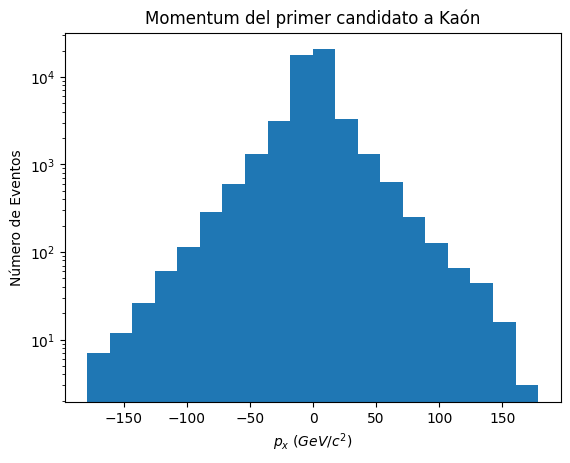

In [ ]:
# Histograma de la variable H1_PX 
h1px = sim_data["H1_PX"]/1000.0
plt.hist(h1px,20,[h1px.min(),h1px.max()])
plt.xlabel(r'$p_x$ ($GeV/c^2$)')
plt.ylabel('Número de Eventos')
plt.yscale('log')
plt.title("Momentum del primer candidato a Kaón")
plt.show()

El momento es una cantidad **vectorial**, tiene componentes x, y, z. Intenta calcular la **magnitud** del momento del primer candidato a kaón y trazar un histograma de esto; necesitarás las variables `H1_PX`, `H1_PY` y `H1_PZ`.

Text(0.5, 1.0, 'Momentum del primer candidato a Kaón')

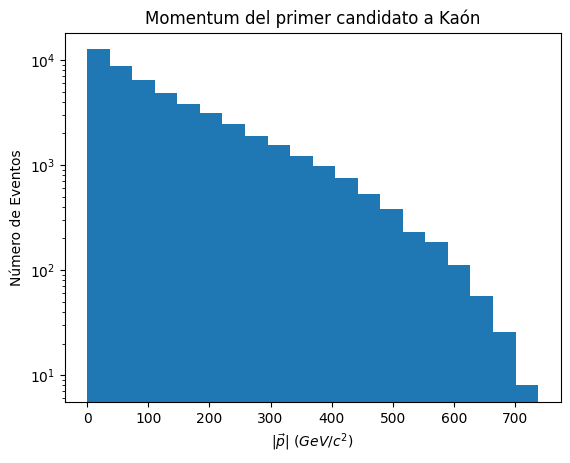

In [ ]:
# Cálculo de una variable para la magnitud del momentum del primer kaón
h1py = sim_data["H1_PY"]/1000.0
h1pz = sim_data["H1_PZ"]/1000.0
h1p = numpy.sqrt(h1px*h1px+h1py*h1py+h1pz*h1pz)
# Histograma de la variable para la magnitud del momentum del primer kaón
plt.hist(h1p,20,[h1p.min(),h1p.max()])
plt.xlabel(r'$|\vec{p}|$ ($GeV/c^2$)')
plt.ylabel('Número de Eventos')
plt.yscale('log')
plt.title("Momentum del primer candidato a Kaón")

### Hints

**Magnitud de un vector**: La magnitud al cuadrado de un vector está dada por la suma de los cuadrados de sus componentes en las direcciones x, y y z: $p^2 = p_x^2+p_y^2+p_z^2$, donde $p$ es la magnitud del momento, y $p_x,p_y,p_z$ son las componentes del momento en las direcciones X, Y y Z.

## Energía y Masa

La teoría de la relatividad especial de Einstein relaciona la energía, la masa y el momento. Hemos medido el momento de los candidatos a kaón en el detector, y acabamos de trazar una de las componentes del momento del kaón, así como la magnitud del momento. La masa invariante del kaón es bien conocida y puedes consultarla. Deseamos determinar la energía de los kaones.

Aquí hay una breve guía sobre la relación energía-momento de la [relatividad especial](Background-Information-Notebooks/SpecialRelativity.ipynb). Puedes encontrar más información en las páginas de Wikipedia sobre [Masa invariante](https://en.wikipedia.org/wiki/Invariant_mass) y la Relación [energía-momento](https://en.wikipedia.org/wiki/Energy%E2%80%93momentum_relation).

Ahora, calcula la energía del primer candidato a kaón usando:

<center> $E^2 = p^2 + m^2$ </center>

In [ ]:
# Cálculo de la energía del primer kaón
mKaon = 0.493 #GeV
h1E = numpy.sqrt(h1p*h1p+mKaon*mKaon)

Text(0.5, 1.0, "First kaon candidate's energy")

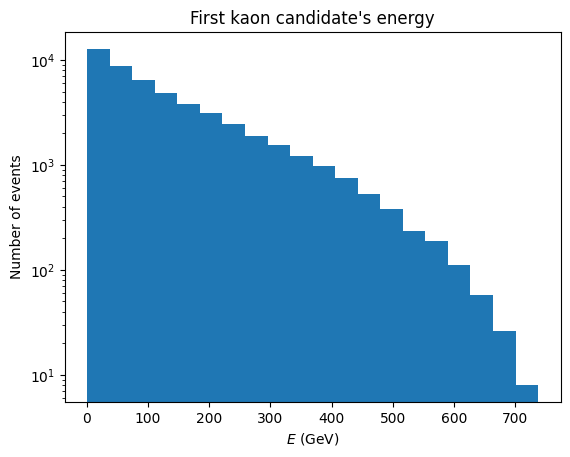

In [ ]:
# Histograma de la energía del primer kaón
plt.hist(h1E,20,[h1E.min(),h1E.max()])
plt.xlabel(r'$E$ (GeV)')
plt.ylabel('Number of events')
plt.yscale('log')
plt.title("First kaon candidate's energy")

### Hints

**Cálculo de la energía** - Usa la variable de magnitud del momento que calculaste arriba y la masa invariante conocida del kaón para calcular la energía del primer hadrón. Calcula la energía al cuadrado, y luego la energía y traza esto.

**Masa del kaón** - Puedes encontrar la masa del kaón en Wikipedia o en libros de texto de física. También hay una referencia utilizada por los físicos de partículas: todo nuestro conocimiento de las propiedades de las partículas está recopilado por el Particle Data Group [aquí](http://pdg.lbl.gov/2014/reviews/rpp2014-rev-charged-kaon-mass.pdf).

Calcula los momentos y las energías del segundo y tercer candidato a kaón.

In [ ]:
# Cálculo de variables para la energía de los otros dos kaones
h2px = sim_data["H2_PX"]/1000.0
h2py = sim_data["H2_PY"]/1000.0
h2pz = sim_data["H2_PZ"]/1000.0
# Energía del segundo kaón
h2E = numpy.sqrt(h2px*h2px+h2py*h2py+h2pz*h2pz+mKaon*mKaon)

In [11]:
# Variables de energía para el tercer kaón
h3px = sim_data["H3_PX"]/1000.0
h3py = sim_data["H3_PY"]/1000.0
h3pz = sim_data["H3_PZ"]/1000.0
# Energía del tercer Kaón
h3E = numpy.sqrt(h3px*h3px+h3py*h3py+h3pz*h3pz+mKaon*mKaon)

## Añadiendo características del mesón $B$
En este análisis, buscamos mesones B<sup>+</sup> o B<sup>-</sup> (ver [mesón B](https://en.wikipedia.org/wiki/B_meson)) que se hayan desintegrado en tres [kaones](https://en.wikipedia.org/wiki/Kaon) cargados.

La energía es una cantidad que se conserva. Esto significa que puedes usar la energía de los tres kaones "hijos", que calculaste anteriormente, para calcular la energía que debió tener el mesón B que se desintegró en ellos.

El momento también es una cantidad que se conserva. Por lo tanto, también puedes usar los momentos de los kaones "hijos" para calcular el momento del mesón B. Pero ten cuidado: el momento es una cantidad *vectorial*.

Usando la energía del mesón B y la magnitud del momento del mesón B, puedes usar nuevamente la relación energía-momento. Esta vez la estás aplicando al mesón B. Esto te permitirá calcular la masa invariante del mesón B.

In [12]:
# calculate the energy of the B meson
BmE = h1E + h2E + h3E

In [ ]:
# Cálculo de los componentes del momentum del mesón B y la magnitud del momentum del mesón B
Bmpx = h1px + h2px + h3px
Bmpy = h1py + h2py + h3py
Bmpz = h1pz + h2pz + h3pz
Bmp = numpy.sqrt(Bmpx*Bmpx + Bmpy*Bmpy + Bmpz*Bmpz)

Text(0.5, 1.0, 'Invarian mass of the B meson')

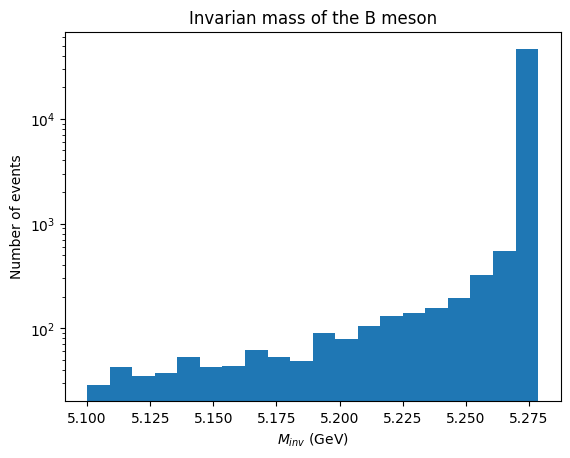

In [ ]:
# Cálculo de la masa invariante del mesón B y la representación gráfica de la masa invariante del mesón B en un histograma
MBm = numpy.sqrt(BmE*BmE-Bmp*Bmp)
plt.hist(MBm,20,[5.1,MBm.max()])
plt.xlabel(r'$M_{inv}$ (GeV)')
plt.ylabel('Number of events')
plt.yscale('log')
plt.title("Invarian mass of the B meson")

Deberías obtener un gráfico que tenga un pico pronunciado en la masa del mesón B<sup>+</sup>. La masa del mesón B<sup>+</sup> y del B<sup>-</sup> son iguales. Verifica que el pico de tu gráfico esté en la [masa conocida](http://pdg.lbl.gov/2014/listings/rpp2014-list-B-plus-minus.pdf) del mesón B. **¡Felicitaciones!**

Recuerda que has hecho este gráfico para datos simulados. ¿Cómo crees que se verían diferentes los gráficos para datos reales? En la siguiente sección comenzarás a trabajar con los datos reales del LHC.

### Hint

**Energía del mesón B** - Por conservación de la energía, la energía del mesón B será la suma de las energías de los tres kaones: $E_B=E_{K1}+E_{K2}+E_{K3}$, donde $E_B$ es la energía del mesón B, $E_{K1}, E_{K2}, E_{K3}$ son las energías de cada uno de los kaones.

**Momento del mesón B** - Por conservación del momento, la componente X del momento del mesón B será la suma de las componentes X del momento de los tres kaones: $px_B=px_{K1}+px_{K2}+px_{K3}$, donde $px$ es la componente en la dirección X del momento del mesón B, $px_{K1},px_{K2},px_{K3}$ son las componentes en la dirección X de los momentos de los tres kaones. Luego puedes hacer lo mismo con las componentes Y y Z. Una vez obtenidas las componentes X, Y y Z del momento del B, puedes encontrar la magnitud del momento del mesón B.

**Masa invariante del mesón B** - Reorganiza la ecuación $E^2=p^2+m^2$ para encontrar $m^2$. Usando los valores de la magnitud del momento del mesón B y la energía del mesón B, encuentra la masa del mesón B.

**Trazado del histograma** - Asegúrate de que el rango de tu gráfico de masa esté configurado adecuadamente para que puedas ver el pico de masa. Una vez que hayas encontrado el pico, puedes ajustar el rango apropiadamente. No es necesario que comiences tu gráfico en una masa de 0.

**Unidades** - Los datos que se te proporcionan tienen energías en 'MeV' (10<sup>6</sup> electronvoltios). La masa del mesón B suele expresarse en 'GeV/c<sup>2</sup>' (10<sup>9</sup> electronvoltios).

# Trabajando con datos reales y aplicando cortes (cuts)

## Objetivos - Desafíos 1 y 2
* Filtrar los datos que no provienen del canal B<sup>+</sup> → K<sup>+</sup>K<sup>+</sup>K<sup>−</sup>, o su equivalente de antipartícula B<sup>-</sup> → K<sup>+</sup>K<sup>-</sup>K<sup>−</sup>

* Trazar un histograma de la masa del mesón B para los datos reales y observar cómo los diferentes cortes afectan los datos
___

En la sección anterior has analizado los datos de simulación para determinar la masa invariante del mesón B. Ahora puedes empezar a aplicar los métodos que has utilizado a los datos reales de LHCb. Estos datos fueron recolectados por el detector LHCb en el CERN durante 2011, el primer año importante de operaciones del LHC.

Los datos que se te han dado han sido filtrados para seleccionar solo eventos que probablemente provengan de mesones B<sup>+</sup> o B<sup>-</sup> desintegrándose en tres partículas finales cargadas. Te interesa el caso en el que estas tres partículas finales son kaones cargados K<sup>+</sup> o K<sup>-</sup>.

Se ha proporcionado una introducción sobre el [detector y la muestra de datos](Background-Information-Notebooks/DetectorSoftwareDataSample.ipynb). Como información de contexto, también proporcionamos más información sobre la [selección](Background-Information-Notebooks/DataSelection.ipynb) que se ha aplicado para seleccionar esta muestra de datos.

## Preselección
Quieres aplicar una preselección a las tres trayectorias del estado final que:
* Asegure que no son muones [ej. `(H1_isMuon==0)`, y similarmente para `H2` y `H3`]
* Requiera que cada una tenga una baja probabilidad de ser piones [ej. `(H1_ProbPi) es una variable de identificación de partículas - probabilidad de H1 de ser un pion`]
* Requiera que cada una tenga una alta probabilidad de ser un kaón [ej. `(H1_ProbK) es una variable de identificación de partículas - probabilidad de H1 de ser un kaón`]

Necesitas encontrar un equilibrio entre hacer cortes demasiado laxos que incluyan demasiados eventos de fondo y cortes demasiado estrictos que rechacen muchos de tus eventos de señal.

Para encontrar los cortes de selección adicionales más adecuados, familiarízate con [cómo los cortes pueden afectar la significancia del resultado final](Background-Information-Notebooks/CutsInformation.ipynb). No dudes en volver a esta etapa más tarde y ajustar tus cortes para ver el impacto.

La preselección que crees se aplicará si le das el nombre 'preselection'.

Hemos proporcionado un ejemplo de preselección en las pistas, así que siéntete libre de usarlo para empezar si lo deseas. Comienza con una preselección laxa y luego refínala después de haber estudiado los gráficos.

In [ ]:
# Preselección de valores
preselection = "(H1_isMuon==0) & (H2_isMuon==0) & (H3_isMuon==0) & (H1_ProbPi<0.5) & (H2_ProbPi<0.5) & (H3_ProbPi<0.5) & (H1_ProbK>0.5) & (H2_ProbK>0.5) & (H3_ProbK>0.5)"

La siguiente línea de código simplemente carga los datos reales en un nuevo DataFrame; esto puede tardar unos minutos.
También aplica la preselección que has creado si la llamaste preselection.

In [16]:
with uproot.open("Data/B2HHH_MagnetUp.root:DecayTree") as data:
    real_data = data.arrays(data.keys(),preselection,library="pd")

with uproot.open("Data/B2HHH_MagnetDown.root:DecayTree") as data:
    real_data._append(data.arrays(data.keys(),preselection,library="pd"), ignore_index=True)

In [17]:
print(f"Eventos combinados: {len(real_data):,}")

Eventos combinados: 9,717


In [18]:
# Códico alternativo
def load_decay_tree(file_path: Path, cut: str | None = None) -> pandas.DataFrame:
    """Cargando el arbol DecayTree de un archivo ROOT como DataFrame"""
    if not file_path.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo: {file_path}"
        )
    with uproot.open(file_path) as root_file:
        if "DecayTree" not in root_file:
            raise KeyError(
                f"El archivo {file_path.name} no contiene un árbol DecayTree"
            )
        tree = root_file["DecayTree"]
        return tree.arrays(
            expressions = tree.keys(),
            cut = cut,
            library="pd"
        )

In [19]:
magnet_up_data = load_decay_tree(DATA_DIR / "B2HHH_MagnetUp.root", cut=preselection)
magnet_down_data = load_decay_tree(DATA_DIR / "B2HHH_MagnetDown.root", cut=preselection)
real_data = pandas.concat(
    [magnet_up_data, magnet_down_data],
    ignore_index=True
)
print(f"Eventos combinados: {len(real_data):,}")
print(f"Eventos Magnet Up: {len(magnet_up_data):,}")
print(f"Eventos Magnet Down: {len(magnet_down_data):,}")

Eventos combinados: 23,895
Eventos Magnet Up: 9,717
Eventos Magnet Down: 14,178


Haz histogramas de la probabilidad de que una partícula del estado final sea un kaón o un pion.
Estos te ayudarán a orientarte sobre los valores de probabilidad adecuados para hacer los cortes.

También puedes considerar opciones más sofisticadas como gráficos 2D de probabilidades de kaón y pion, o diferentes valores de los cortes para las diferentes partículas del estado final.

Text(0.5, 1.0, 'Probabilidad de que el primer estado final sea un kaón')

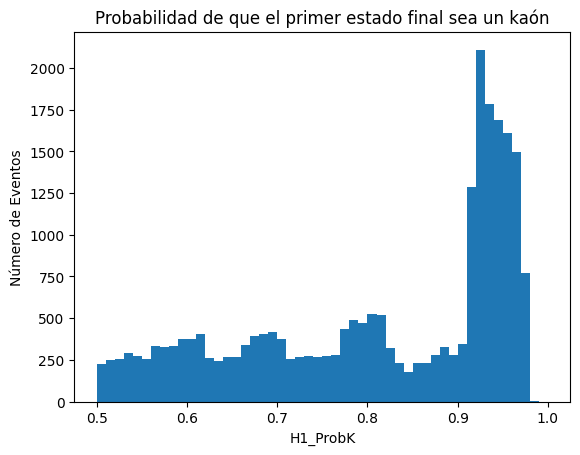

In [ ]:
# Gráfica de la probabilidad de que una partícula del estado final sea un kaón
plt.hist(real_data['H1_ProbK'],50,[0.5,1])
plt.xlabel(r'H1_ProbK')
plt.ylabel('Número de Eventos')

plt.title("Probabilidad de que el primer estado final sea un kaón")

Text(0.5, 1.0, 'Probabilidad de que el primer estado final sea un kaón (Magnet Up)')

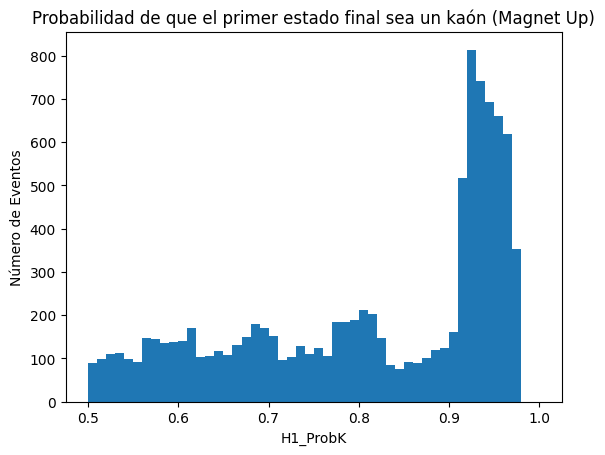

In [21]:
plt.hist(magnet_up_data['H1_ProbK'],50,[0.5,1])
plt.xlabel(r'H1_ProbK')
plt.ylabel('Número de Eventos')

plt.title("Probabilidad de que el primer estado final sea un kaón (Magnet Up)")

Text(0.5, 1.0, 'Probabilidad de que el primer estado final sea un kaón (Magnet Down)')

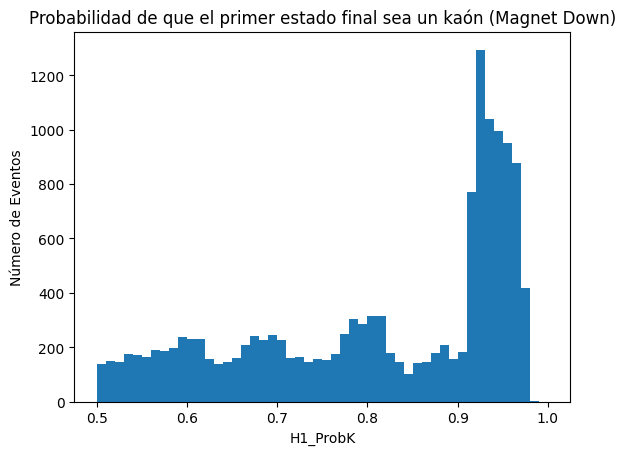

In [22]:
plt.hist(magnet_down_data['H1_ProbK'],50,[0.5,1])
plt.xlabel(r'H1_ProbK')
plt.ylabel('Número de Eventos')

plt.title("Probabilidad de que el primer estado final sea un kaón (Magnet Down)")

Text(0.5, 1.0, 'Probabilidad de que el primer estado final sea un pion')

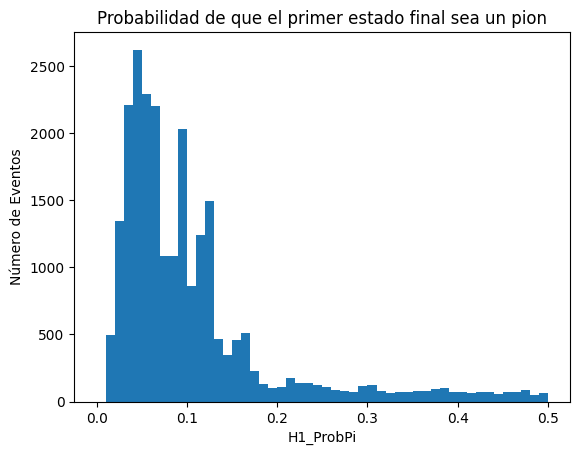

In [ ]:
# Gráfica de la probabilidad de que una partícula del estado final sea un pion
plt.hist(real_data['H1_ProbPi'],50,[0,0.5])
plt.xlabel(r'H1_ProbPi')
plt.ylabel('Número de Eventos')
plt.title("Probabilidad de que el primer estado final sea un pion")

Text(0.5, 1.0, 'Probabilidad de que el primer estado final sea un pion (Magnet Up)')

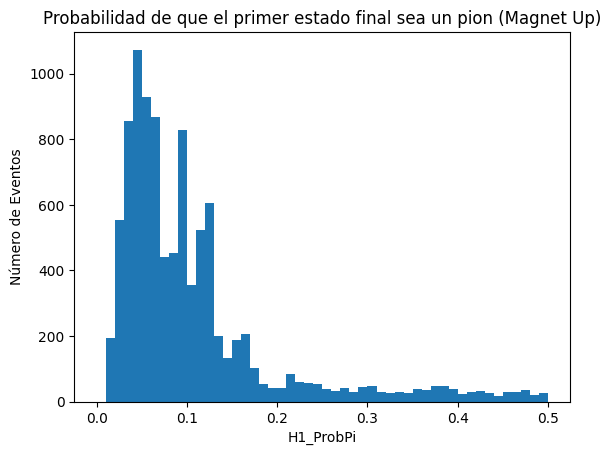

In [24]:
plt.hist(magnet_up_data['H1_ProbPi'],50,[0,0.5])
plt.xlabel(r'H1_ProbPi')
plt.ylabel('Número de Eventos')
plt.title("Probabilidad de que el primer estado final sea un pion (Magnet Up)")

Text(0.5, 1.0, 'Probabilidad de que el primer estado final sea un pion (Magnet Down)')

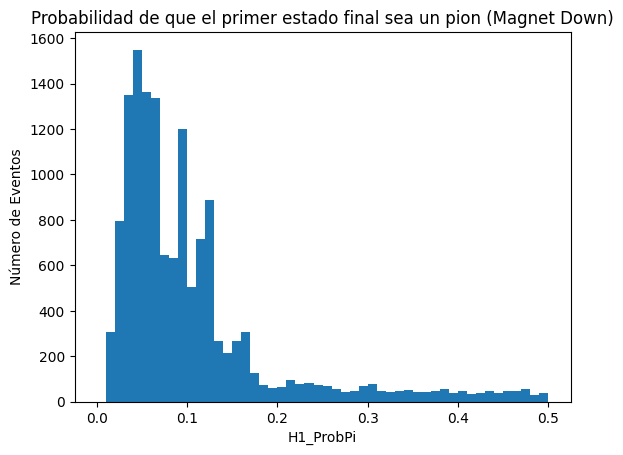

In [25]:
plt.hist(magnet_down_data['H1_ProbPi'],50,[0,0.5])
plt.xlabel(r'H1_ProbPi')
plt.ylabel('Número de Eventos')
plt.title("Probabilidad de que el primer estado final sea un pion (Magnet Down)")

Text(0.5, 1.0, 'Probabilidad de que el primer estado final sea un Kaón o un Pion')

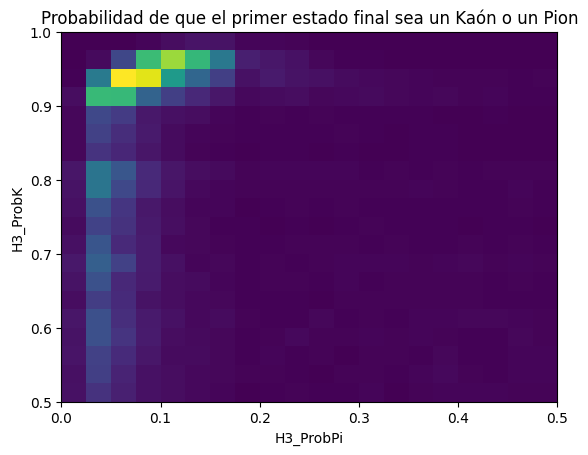

In [26]:
# plot the probability that a final state particle is a pion
plt.hist2d(real_data['H1_ProbPi'],real_data['H1_ProbK'],20,[[0,0.5],[0.5,1]])
plt.xlabel(r'H3_ProbPi')
plt.ylabel(r'H3_ProbK')
plt.title("Probabilidad de que el primer estado final sea un Kaón o un Pion")

Text(0.5, 1.0, 'Probabilidad de que el primer estado final sea un Kaón o un Pion (Magnet Up)')

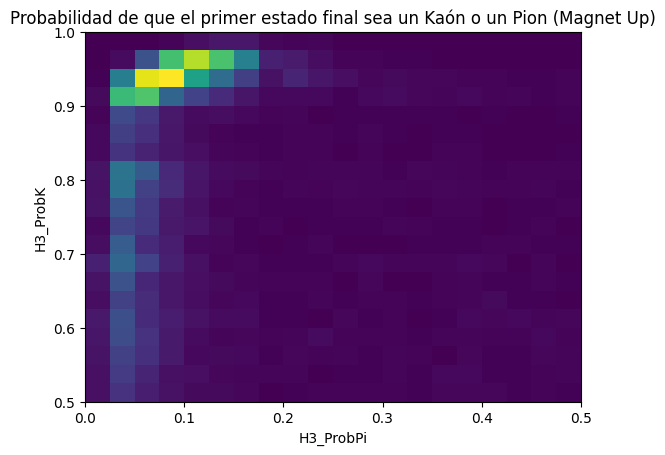

In [27]:
plt.hist2d(magnet_up_data['H1_ProbPi'],magnet_up_data['H1_ProbK'],20,[[0,0.5],[0.5,1]])
plt.xlabel(r'H3_ProbPi')
plt.ylabel(r'H3_ProbK')
plt.title("Probabilidad de que el primer estado final sea un Kaón o un Pion (Magnet Up)")

Text(0.5, 1.0, 'Probabilidad de que el primer estado final sea un Kaón o un Pion (Magnet Down)')

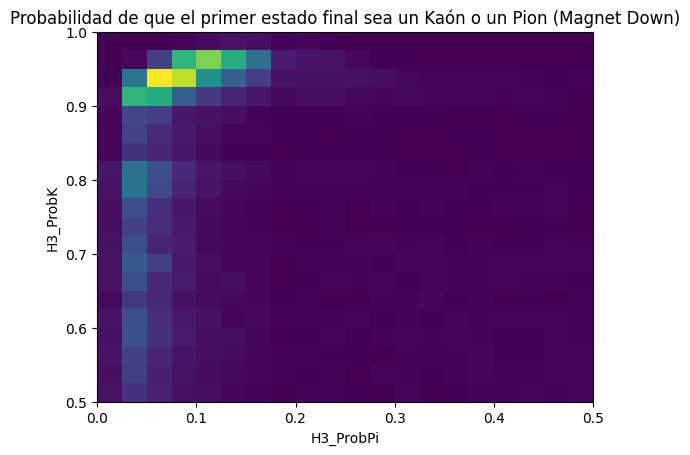

In [28]:
plt.hist2d(magnet_down_data['H1_ProbPi'],magnet_down_data['H1_ProbK'],20,[[0,0.5],[0.5,1]])
plt.xlabel(r'H3_ProbPi')
plt.ylabel(r'H3_ProbK')
plt.title("Probabilidad de que el primer estado final sea un Kaón o un Pion (Magnet Down)")

Ahora calcula la masa invariante del mesón B para los datos reales y traza un histograma de esto.
Compáralo con el que hiciste para los datos de simulación.

¿Puedes explicar las diferencias que observas?

Text(0.5, 1.0, 'Masa invariante del mesón B')

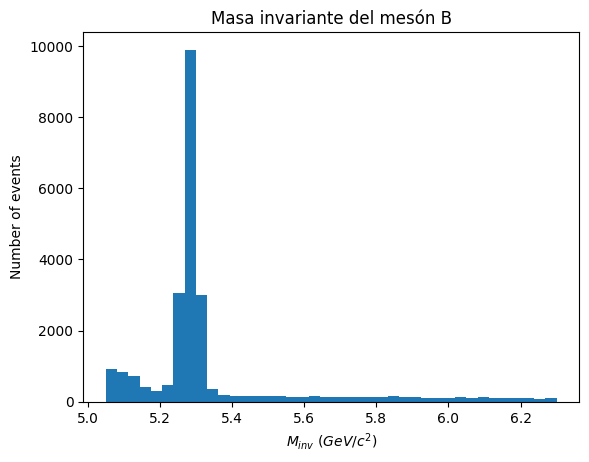

In [ ]:
# Histograma para la masa del mesón B en los datos reales
massKaon = 493.68 #MeV - masa invariante del mesón B
real_data = real_data.eval('H1_E = sqrt(493.68**2 + H1_PX**2 + H1_PY**2 + H1_PZ**2)')
real_data = real_data.eval('H2_E = sqrt(493.68**2 + H2_PX**2 + H2_PY**2 + H2_PZ**2)')
real_data = real_data.eval('H3_E = sqrt(493.68**2 + H3_PX**2 + H3_PY**2 + H3_PZ**2)')
real_data = real_data.eval('B_M = sqrt( (H1_E + H2_E + H3_E)**2 - (H1_PX+H2_PX+H3_PX)**2 - (H1_PY+H2_PY+H3_PY)**2 - (H1_PZ+H2_PZ+H3_PZ)**2  )')

# plt.hist(real_data['B_M'],20,[real_data['B_M'].min(),real_data['B_M'].max()])
plt.hist(real_data['B_M']/1000.0,40)
plt.xlabel(r'$M_{inv}$ ($GeV/c^2$)')
plt.ylabel('Eventos')
plt.title("Masa invariante del mesón B")

Text(0.5, 1.0, 'Masa invariante del mesón B (Magnet Up)')

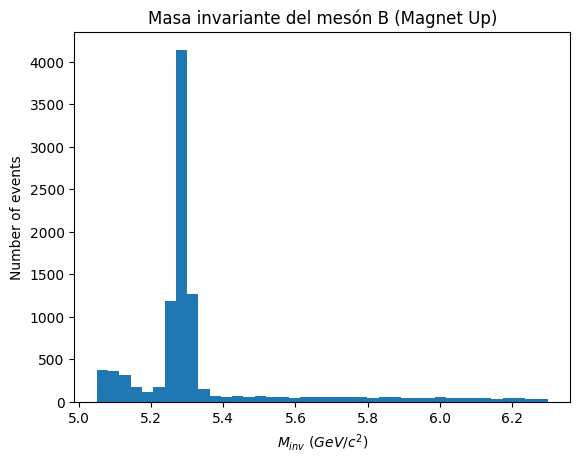

In [ ]:
magnet_up_data = magnet_up_data.eval('H1_E = sqrt(493.68**2 + H1_PX**2 + H1_PY**2 + H1_PZ**2)')
magnet_up_data = magnet_up_data.eval('H2_E = sqrt(493.68**2 + H2_PX**2 + H2_PY**2 + H2_PZ**2)')
magnet_up_data = magnet_up_data.eval('H3_E = sqrt(493.68**2 + H3_PX**2 + H3_PY**2 + H3_PZ**2)')
magnet_up_data = magnet_up_data.eval('B_M = sqrt( (H1_E + H2_E + H3_E)**2 - (H1_PX+H2_PX+H3_PX)**2 - (H1_PY+H2_PY+H3_PY)**2 - (H1_PZ+H2_PZ+H3_PZ)**2  )')

# plt.hist(real_data['B_M'],20,[real_data['B_M'].min(),real_data['B_M'].max()])
plt.hist(magnet_up_data['B_M']/1000.0,40)
plt.xlabel(r'$M_{inv}$ ($GeV/c^2$)')
plt.ylabel('Eventos')
plt.title("Masa invariante del mesón B (Magnet Up)")

Text(0.5, 1.0, 'Masa invariante del mesón B (Magnet Down)')

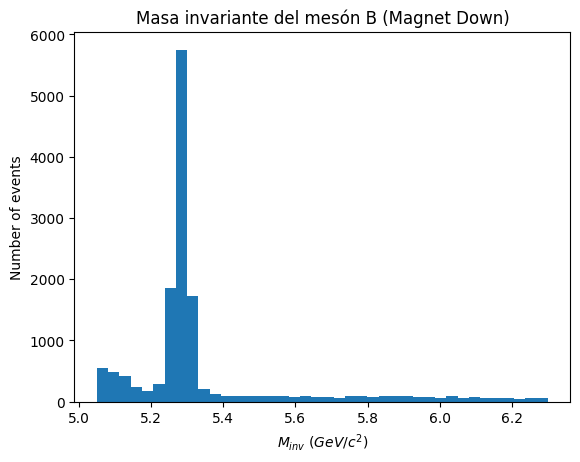

In [31]:
magnet_down_data = magnet_down_data.eval('H1_E = sqrt(493.68**2 + H1_PX**2 + H1_PY**2 + H1_PZ**2)')
magnet_down_data = magnet_down_data.eval('H2_E = sqrt(493.68**2 + H2_PX**2 + H2_PY**2 + H2_PZ**2)')
magnet_down_data = magnet_down_data.eval('H3_E = sqrt(493.68**2 + H3_PX**2 + H3_PY**2 + H3_PZ**2)')
magnet_down_data = magnet_down_data.eval('B_M = sqrt( (H1_E + H2_E + H3_E)**2 - (H1_PX+H2_PX+H3_PX)**2 - (H1_PY+H2_PY+H3_PY)**2 - (H1_PZ+H2_PZ+H3_PZ)**2  )')

# plt.hist(real_data['B_M'],20,[real_data['B_M'].min(),real_data['B_M'].max()])
plt.hist(magnet_down_data['B_M']/1000.0,40)
plt.xlabel(r'$M_{inv}$ ($GeV/c^2$)')
plt.ylabel('Number of events')
plt.title("Masa invariante del mesón B (Magnet Down)")

Experimenta con los cortes y observa el impacto de cortes más severos o más indulgentes en el gráfico de masa invariante.
Debes seleccionar un conjunto de cortes que haga que la señal sea más prominente con respecto al fondo.
Una vez que hayas finalizado la selección sobre la identificación de partículas, también aplica cortes en la masa reconstruida de la partícula para seleccionar los eventos en el pico de masa del mesón B, eliminando los eventos de fondo que se encuentran en masas invariantes más bajas y más altas.

In [32]:
# Otra preselección
preselection_2 = "(H1_ProbPi < 0.3) & (H2_ProbPi < 0.3) & (H3_ProbPi < 0.3) & (H1_ProbK > 0.7) & (H2_ProbK > 0.7) & (H3_ProbK > 0.7) & (H1_isMuon==0) & (H2_isMuon==0) & (H3_isMuon==0)"

In [33]:
magnet_up_data_2 = load_decay_tree(DATA_DIR / "B2HHH_MagnetUp.root", cut=preselection_2)
magnet_down_data_2 = load_decay_tree(DATA_DIR / "B2HHH_MagnetDown.root", cut=preselection_2)
real_data_2 = pandas.concat(
    [magnet_up_data_2, magnet_down_data_2],
    ignore_index=True
)
print(f"Eventos combinados: {len(real_data_2):,}")
print(f"Eventos Magnet Up: {len(magnet_up_data_2):,}")
print(f"Eventos Magnet Down: {len(magnet_down_data_2):,}")

Eventos combinados: 8,849
Eventos Magnet Up: 3,664
Eventos Magnet Down: 5,185


Text(0.5, 1.0, 'Probabilidad de que el primer estado final sea un kaón')

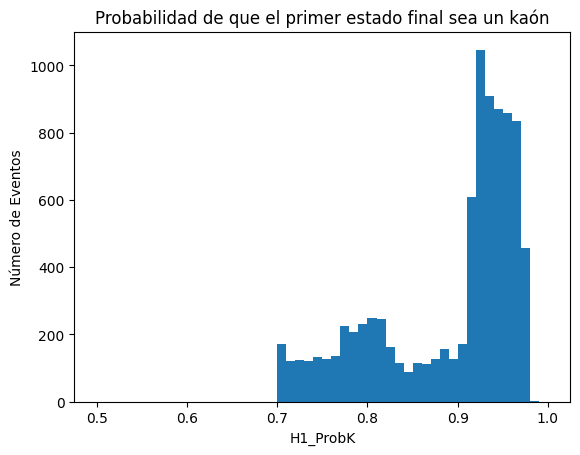

In [34]:
# plot the probability that a final state particle is a kaon
plt.hist(real_data_2['H1_ProbK'],50,[0.5,1])
plt.xlabel(r'H1_ProbK')
plt.ylabel('Número de Eventos')

plt.title("Probabilidad de que el primer estado final sea un kaón")

Text(0.5, 1.0, 'Probabilidad de que el primer estado final sea un pion')

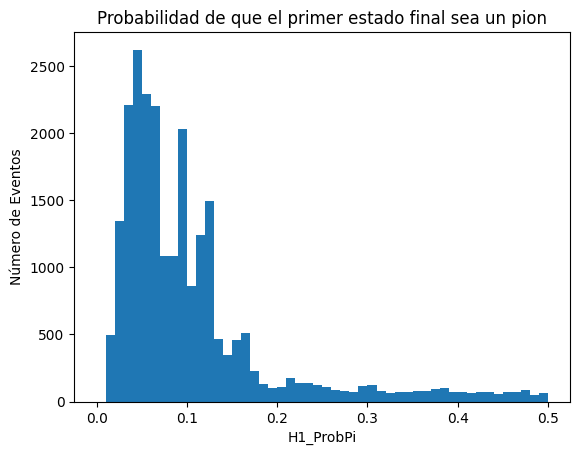

In [35]:
# plot the probability that a final state particle is a pion
plt.hist(real_data['H1_ProbPi'],50,[0,0.5])
plt.xlabel(r'H1_ProbPi')
plt.ylabel('Número de Eventos')
plt.title("Probabilidad de que el primer estado final sea un pion")

Text(0.5, 1.0, 'Probabilidad de que el primer estado final sea un Kaón o un Pion')

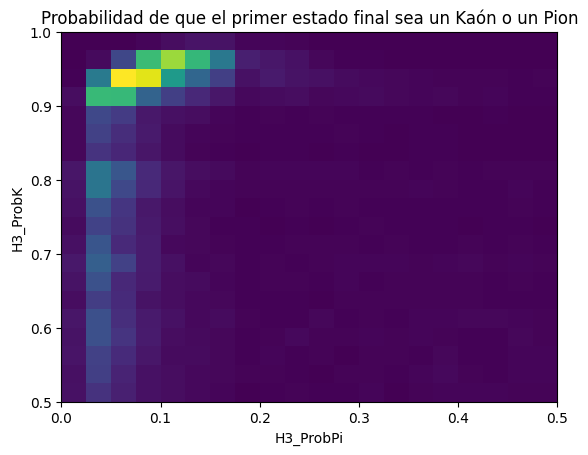

In [36]:
# plot the probability that a final state particle is a pion
plt.hist2d(real_data['H1_ProbPi'],real_data['H1_ProbK'],20,[[0,0.5],[0.5,1]])
plt.xlabel(r'H3_ProbPi')
plt.ylabel(r'H3_ProbK')
plt.title("Probabilidad de que el primer estado final sea un Kaón o un Pion")

Text(0.5, 1.0, 'Masa invariante del mesón B')

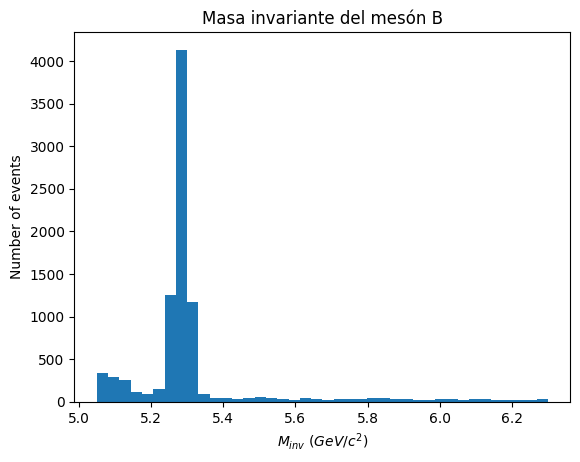

In [ ]:
# draw a histogram for the B meson mass in the real data
massKaon = 493.68 #MeV
real_data_2 = real_data_2.eval('H1_E = sqrt(493.68**2 + H1_PX**2 + H1_PY**2 + H1_PZ**2)')
real_data_2 = real_data_2.eval('H2_E = sqrt(493.68**2 + H2_PX**2 + H2_PY**2 + H2_PZ**2)')
real_data_2 = real_data_2.eval('H3_E = sqrt(493.68**2 + H3_PX**2 + H3_PY**2 + H3_PZ**2)')
real_data_2 = real_data_2.eval('B_M = sqrt( (H1_E + H2_E + H3_E)**2 - (H1_PX+H2_PX+H3_PX)**2 - (H1_PY+H2_PY+H3_PY)**2 - (H1_PZ+H2_PZ+H3_PZ)**2  )')

# plt.hist(real_data['B_M'],20,[real_data['B_M'].min(),real_data['B_M'].max()])
plt.hist(real_data_2['B_M']/1000.0,40)
plt.xlabel(r'$M_{inv}$ ($GeV/c^2$)')
plt.ylabel('Number of events')
plt.title("Masa invariante del mesón B")

# Buscando diferencias globales entre materia y antimateria

En esta sección comenzarás a estudiar las diferencias entre materia y antimateria (violación CP). Aquí, "global" significa que estás buscando diferencias en todos los rangos de energía y momento (la cinemática) de los kaones en los que se han desintegrado los mesones B cargados. Más adelante veremos diferencias "locales" en diferentes regiones de la cinemática.

## Objetivos:
* Calcular la asimetría CP global
* Calcular la incertidumbre estadística
* Determinar si hay evidencia de violación de CP en esta desintegración
___

Para cuantificar la asimetría materia-antimateria en este proceso, deseamos comparar las partículas B<sup>+</sup> y B<sup>-</sup>. El B<sup>-</sup> es la antipartícula del B<sup>+</sup>.

¿Cómo puedes distinguir entre eventos que contienen partículas B<sup>+</sup> y B<sup>-</sup> usando `H1_Charge`, `H2_Charge` y `H3_Charge`?

In [ ]:
# Variable para la carga de los mesones B
real_data = real_data.eval('B_Charge = H1_Charge + H2_Charge + H3_Charge')
real_data_2 = real_data_2.eval('B_Charge = H1_Charge + H2_Charge + H3_Charge')

Ahora cuenta los números de eventos de cada uno de los dos tipos (N<sup>+</sup> y N<sup>-</sup>). También calcula la diferencia entre estos dos números.

In [ ]:
# Variables para s números de mesones B positivos y negativos
# Np = sum(real_data['B_Charge']>0)
Np = len(real_data.query('B_Charge == 1'))
# Nm = sum(real_data['B_Charge']<0)
Nm = len(real_data.query('B_Charge == -1'))
print(Np, Nm, Np-Nm)

12390 11505 885


In [40]:
# Np = sum(real_data['B_Charge']>0)
Np_2 = len(real_data_2.query('B_Charge == 1'))
# Nm = sum(real_data['B_Charge']<0)
Nm_2 = len(real_data_2.query('B_Charge == -1'))
print(Np_2, Nm_2, Np_2-Nm_2)

4607 4242 365


Para calcular la asimetría, puedes usar la fórmula:

<img src="Images/AsymmetryEq.png" width="200" />

In [ ]:
# Cálculo del valor de la asimetría, usando la fórmula anterior
A = (Nm-Np)/(Nm+Np)
print("A = ",A)

A =  -0.037037037037037035


In [42]:
A2 = (Nm_2-Np_2)/(Nm_2+Np_2)
print("A = ",A2)

A =  -0.041247598598711716


### Hint

**Diferenciando entre N+ y N-**

- La carga es una cantidad que se conserva. La carga del mesón $B$ es igual a la suma de las cargas de las partículas en las que se desintegra.
- Se puede usar `len(real_data.query('B_Charge == charge'))` para contar el número de mesones, donde `B_Charge` es la variable que creaste y charge es `1` o `-1`.

### Estimando la significancia de la desviación
Ahora necesitarás calcular la incertidumbre estadística de la asimetría. Puedes hacerlo usando la fórmula: 
<img src="Images/AsymmetryErrorEq.png" width="200" />

La significancia del resultado, sigma, se obtiene dividiendo el valor de la asimetría por su incertidumbre. Un valor que supere tres sigma se considera "evidencia" por los físicos de partículas, mientras que un valor de cinco sigma o más puede llamarse "observación" o "descubrimiento".

In [43]:
# calculate the statistical significance of your result and print it
sigma_A = numpy.sqrt((1-A**2)/(Nm+Np))
significance = A/sigma_A
print("Statistical significance of the asymmetry, sigma_A =",significance)

sigma_A2 = numpy.sqrt((1-A2**2)/(Nm_2+Np_2))
significance2 = A2/sigma_A2
print("Statistical significance of the asymmetry, sigma_A =",significance2)

Statistical significance of the asymmetry, sigma_A = -5.729118797668817
Statistical significance of the asymmetry, sigma_A = -3.883430418976701


**¡Felicitaciones!** Has realizado tu primera búsqueda de una diferencia entre materia y antimateria.

Aquí solo has considerado la incertidumbre estadística. Tu medición también tendrá otras fuentes de incertidumbre conocidas como incertidumbres sistemáticas, que no has considerado en esta etapa.

# Diagramas de Dalitz y resonancias de dos cuerpos

## Objetivos:
* Producir diagramas de Dalitz de la muestra de datos simulados y reales
* Crear diagramas de Dalitz ordenados y binned (con intervalos)
* Identificar resonancias de dos cuerpos en los diagramas de Dalitz
____

En esta etapa te introducimos a una técnica importante para analizar desintegraciones de una partícula (tu mesón B cargado) en tres cuerpos (los tres kaones). Esto se conoce como diagrama de Dalitz.

La desintegración del mesón B puede ocurrir directamente al estado final de tres cuerpos o a través de una partícula intermedia. Por ejemplo, B<sup>+</sup> → K<sup>+</sup>K<sup>+</sup>K<sup>−</sup> podría ocurrir a través de la desintegración B<sup>+</sup> → K<sup>+</sup>R<sup>0</sup>, donde R<sup>0</sup> es una resonancia de partícula neutra que puede desintegrarse R<sup>0</sup> → K<sup>+</sup>K<sup>-</sup>. Los diagramas de Dalitz se pueden usar para identificar estas resonancias, que son visibles como bandas en el diagrama de Dalitz.

Puedes encontrar más información sobre estos diagramas y por qué se usan en la investigación en física de partículas en la [Introducción al Diagrama de Dalitz](Background-Information-Notebooks/DalitzPlots.ipynb).

La cinemática de una desintegración de tres cuerpos se puede describir completamente usando solo dos variables. Las energías y momentos de los tres kaones no son independientes entre sí porque todos provienen de la desintegración de un mesón B y la energía y el momento se conservan. Los ejes de los diagramas convencionalmente son las masas invariantes al cuadrado de dos pares de los productos de desintegración. Es un gráfico 2D, los ejes x e y son ambas masas al cuadrado y la densidad de puntos en el gráfico muestra la estructura.

Considera nuestra desintegración B<sup>+</sup> → K<sup>+</sup><sub>1</sub>K<sup>+</sup><sub>2</sub>K<sup>−</sup><sub>3</sub>, donde hemos numerado los kaones 1, 2, 3 para distinguirlos. Podemos calcular la masa invariante de tres combinaciones posibles que podrían corresponder a resonancias intermedias R<sup>++</sup><sub>1</sub> → K<sup>+</sup><sub>1</sub>K<sup>+</sup><sub>2</sub>, R<sup>0</sup><sub>2</sub> → K<sup>+</sup><sub>1</sub>K<sup>-</sup><sub>3</sub>, y R<sup>0</sup><sub>3</sub> → K<sup>+</sup><sub>3</sub>K<sup>-</sup><sub>3</sub>.

La potencial R<sup>++</sup><sub>1</sub> sería una resonancia doblemente cargada. No esperaríamos ver ninguna resonancia correspondiente a esto, ya que los mesones están compuestos por un quark y un antiquark y sus cargas no pueden sumar dos unidades.

Las potenciales R<sup>0</sup><sub>2</sub> y R<sup>0</sup><sub>3</sub> corresponden a configuraciones en las que podríamos ver resonancias. Por lo tanto, debes calcular las combinaciones de masa invariante para estas. El cuadrado de estas masas debe usarse como las variables de Dalitz.

Te sugerimos que hagas estos gráficos primero con los datos de simulación. En la simulación no hay resonancias intermedias y tu gráfico debería tener una densidad uniforme dentro del rango físicamente permitido por la conservación de energía y momento.

In [ ]:
# Cálculo de las masas invariantes para cada posible combinación de pares de hadrones
R02_m2 = (h1E+h3E)**2 - (h1px+h3px)**2 - (h1py+h3py)**2 - (h1pz+h3pz)**2
R03_m2 = (h1E+h2E)**2 - (h1px+h2px)**2 - (h1py+h2py)**2 - (h1pz+h2pz)**2

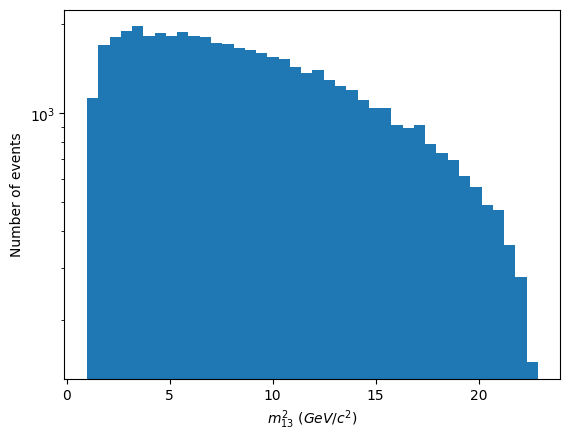

In [ ]:
# Gráfica de la masa invariante para una combinación de pares de hadrones
plt.hist(R02_m2,40,[R02_m2.min(),R02_m2.max()])
plt.xlabel(r'$m_{13}^2$ ($GeV/c^2$)')
plt.ylabel('Number of events')
plt.yscale('log')

Text(0, 0.5, '$m_{12}^2$ ($GeV^2$)')

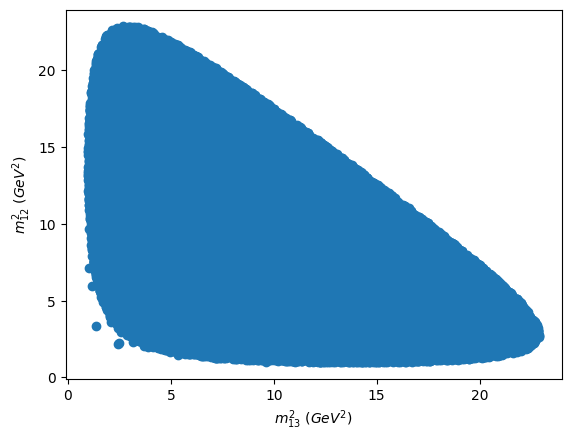

In [ ]:
# Gráfica de Dalitz con ejes etiquetados para los datos de la simulación
plt.scatter(R02_m2,R03_m2)
plt.xlabel(r'$m_{13}^2$ ($GeV^2$)')
plt.ylabel(r'$m_{12}^2$ ($GeV^2$)')

### Hints

**Cálculo de la masa invariante** - Usa la misma técnica que usaste arriba para el mesón B, pero ahora aplicándola a masas invariantes de dos cuerpos en lugar de tres.

**Trazado del diagrama de Dalitz** - Puedes usar un gráfico de `scatter` (dispersión) de `matplotlib` para trazar un diagrama de Dalitz; consulta el [análisis de ejemplo](Example-Analysis.ipynb). Recuerda usar el cuadrado de cada masa de dos cuerpos.

## Añadiendo el diagrama de Dalitz para datos reales

Ahora dibuja un diagrama de Dalitz para los datos reales. Verifica que los signos de las cargas de los hadrones sean correctos para corresponder a tus potenciales resonancias neutras R<sup>0</sup><sub>2</sub> y R<sup>0</sup><sub>3</sub>.

In [ ]:
# Cálculo de las masas invariantes para cada posible combinación de pares de hadrones en los datos reales
real_data = real_data.query('(B_M>5194) & (B_M<5364)')
real_data = real_data.eval('R02_m2 = (H1_E+H3_E)**2 - (H1_PX+H3_PX)**2 - (H1_PY+H3_PY)**2 - (H1_PZ+H3_PZ)**2')
real_data = real_data.eval('R03_m2 = (H1_E+H2_E)**2 - (H1_PX+H2_PX)**2 - (H1_PY+H2_PY)**2 - (H1_PZ+H2_PZ)**2')

Text(0, 0.5, '$m_{12}^2$ ($GeV^2$)')

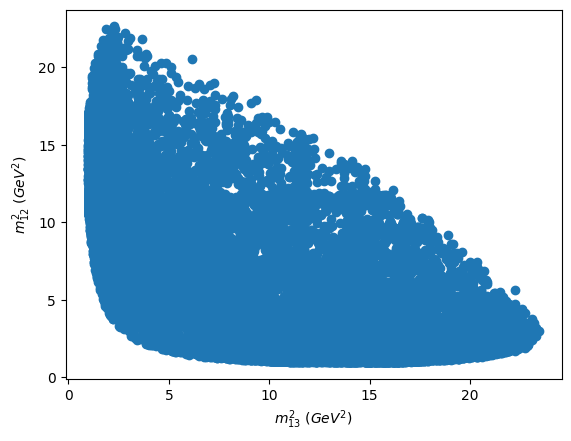

In [ ]:
# Gráfico de Dalitz para los datos reales (con los cortes de preselección aplicados)
plt.scatter(real_data['R02_m2']/1E6,real_data['R03_m2']/1E6)
plt.xlabel(r'$m_{13}^2$ ($GeV^2$)')
plt.ylabel(r'$m_{12}^2$ ($GeV^2$)')

<div align="justify">Al dibujar el diagrama de Dalitz para los datos reales, etiqueta los ejes adecuadamente. Compara los diagramas de Dalitz de los datos reales con el de la simulación. ¿Cuáles son las diferencias más notables? </div>

### Ordenando las variables de Dalitz

Puedes hacer una mejora adicional para observar las resonancias más fácilmente. Tus resonancias R<sup>0</sup><sub>2</sub> y R<sup>0</sup><sub>3</sub> están compuestas por los mismos tipos de partículas, K<sup>+</sup>K<sup>-</sup>, y por lo tanto tienen las mismas distribuciones. Es útil imponer un orden que distinga las resonancias. Podemos llamar a las resonancias R<sup>0</sup><sub>Low</sub> y R<sup>0</sup><sub>High</sub>. En cada evento, R<sup>0</sup><sub>Low</sub> es la resonancia con la masa más baja y la otra corresponde a la combinación de kaones de mayor masa. Ahora puedes usar la masa de estas resonancias ordenadas como tus variables del diagrama de Dalitz, "plegando" efectivamente tu diagrama de Dalitz de modo que un eje siempre tenga un valor más alto que el otro.

Text(0, 0.5, '$m_{12}^2$ ($GeV^2$)')

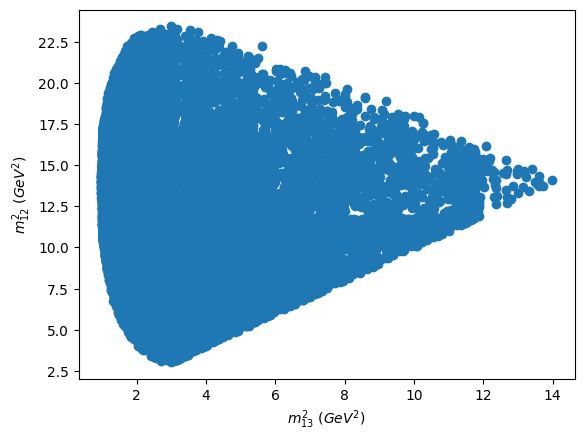

In [ ]:
# Gráfico de Dalitz con un orden de masas de los ejes
R0low = real_data[['R02_m2','R03_m2']].min(axis=1)
R0high = real_data[['R02_m2','R03_m2']].max(axis=1)
plt.scatter(R0low/1E6,R0high/1E6)
plt.xlabel(r'$m_{13}^2$ ($GeV^2$)')
plt.ylabel(r'$m_{12}^2$ ($GeV^2$)')

### Hint

**Diagrama de Dalitz ordenado** - Puedes encontrar el máximo de la masa de R<sup>0</sup><sub>Low</sub> vs R<sup>0</sup><sub>High</sub> elemento por elemento en un eje, y el mínimo en el otro. Puedes realizar comparaciones elemento por elemento entre dos arreglos y devolver un arreglo llenado ya sea con el elemento mínimo o máximo individual de las comparaciones elemento por elemento.

### Diagrama de Dalitz con intervalos (binned)
Puedes mejorar la representación de tu diagrama de Dalitz agrupando los datos en intervalos (bins). La función hist2d se puede usar para hacer un histograma 2D. La especificación del número de intervalos (bins) en la función hist2d es el número de intervalos en un eje.

Text(0, 0.5, '$m_{high}^2$ ($GeV^2$)')

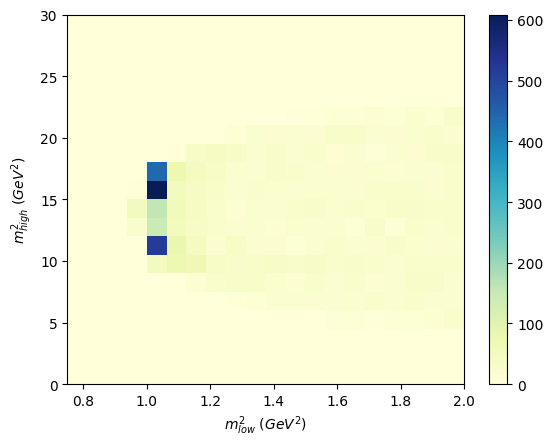

In [ ]:
# Gráfico de Dalitz agrupado - se usó colorbar() para crear una leyenda al lado del gráfico
plt.hist2d(R0low/1E6,R0high/1E6,20,[[0.75,2],[0,30]],cmap='YlGnBu')
plt.colorbar()
plt.xlabel(r'$m_{low}^2$ ($GeV^2$)')
plt.ylabel(r'$m_{high}^2$ ($GeV^2$)')

Text(0, 0.5, 'Number of events')

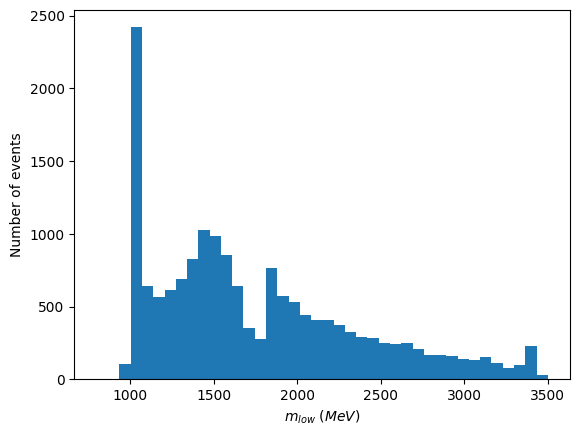

In [51]:
plt.hist(numpy.sqrt(R0low),40,[800,3500])
plt.xlabel(r'$m_{low}$ ($MeV$)')
plt.ylabel('Number of events')

## Resonancias de dos cuerpos


Ahora puedes usar tu diagrama de Dalitz para identificar las resonancias intermedias que ves en tus gráficos. Las resonancias aparecerán como bandas de mayor densidad de puntos en los gráficos. Puedes usar las tablas de mesones del [Particle Data Group](http://pdg.lbl.gov/2015/tables/contents_tables.html) para identificar a qué partículas corresponden. Las tablas proporcionan las masas y anchos de las partículas y sus modos de desintegración. Buscas mesones con masas que correspondan a donde ves las bandas y que se desintegren en K<sup>+</sup>K<sup>-</sup>.

**¡Felicitaciones!** Has creado exitosamente un diagrama de Dalitz y lo has usado para observar la presencia de partículas intermedias en la desintegración de tu mesón B cargado en tres kaones cargados.

# Buscando diferencias locales entre materia y antimateria
## Objetivos:
* Observar diferencias entre materia y antimateria (violación CP) en regiones de los diagramas de Dalitz de los mesones B<sup>+</sup> y B<sup>-</sup>.
* Para los datos en estas regiones, producir gráficos que muestren de la mejor manera la violación CP.

En una sección anterior buscaste violación CP global. Probablemente no encontraste un resultado con una significancia muy alta.

La violación CP puede surgir de la interferencia entre desintegraciones a través de diferentes resonancias, y por lo tanto la magnitud y el signo de la violación CP pueden variar a lo largo del diagrama de Dalitz. Podemos aplicar la misma ecuación que en el estudio de violación CP global
<img src="Images/AsymmetryEq.png" width="200" />
pero aplicarla solo a eventos en regiones particulares del diagrama de Dalitz.

## Eliminando resonancias de charm

El análisis que se realiza aquí es para estudiar la violación CP en desintegraciones de mesones B sin charm hacia kaones. "Sin charm" significa que la desintegración no ocurre a través de un quark charm. Sin embargo, la desintegración más frecuente de los mesones B ocurre a través del quark *b* desintegrándose en un quark *c*. La mayoría de estos eventos se pueden eliminar rechazando los eventos que ocurren a través de un mesón D<sup>0</sup> (que contiene el quark charm).

En la sección anterior trazaste un histograma de la masa invariante de las resonancias intermedias y habrás observado el mesón D<sup>0</sup> en este y en el diagrama de Dalitz. Ahora deberías rechazar los eventos que están alrededor del rango de masa del mesón D<sup>0</sup> para suprimir esta contribución. Puedes hacer esto en tu preselección de datos que configuraste al principio del proyecto.

Esta fue también una simplificación que no consideramos cuando calculamos la asimetría global. Después de haber aplicado esta preselección, tu código recomputará la asimetría global con la contribución del mesón D<sup>0</sup> rechazada. Todavía no hemos observado violación CP en mesones charm, y buscar esto es otra área activa de investigación actual.

## Comparando diagramas de Dalitz

Haz diagramas de Dalitz separados para las desintegraciones de B<sup>+</sup> y B<sup>-</sup>.
La violación CP local se mostrará como una asimetría entre los gráficos de B<sup>+</sup> y B<sup>-</sup>.

Para que el error estadístico sobre la asimetría en cada intervalo (bin) no sea demasiado grande, los intervalos deben contener un número razonable de entradas. Por lo tanto, probablemente necesitarás intervalos más grandes que cuando buscabas resonancias en la sección anterior. Un tamaño de intervalo inicial adecuado podría ser $2.5~\text{GeV}^2/\text{c}^4 \times 2.5~\text{GeV}^2/\text{c}^4$.

In [52]:
# Eliminando las resonancias charm
# real_data = real_data.query('(sqrt(B_m2)<5330) & (sqrt(B_m2)>5228)')
real_data = real_data.query('((R02_m2<R03_m2) & ( (R02_m2<1800**2) | (R02_m2>2000**2))) | ((R02_m2>R03_m2) & ( (R03_m2<1800**2) | (R03_m2>2000**2)))')
Bp_real_data = real_data.query('(B_Charge == 1)')
R0low = Bp_real_data[['R02_m2','R03_m2']].min(axis=1)
R0high = Bp_real_data[['R02_m2','R03_m2']].max(axis=1)

Text(0, 0.5, '$m_{high}^2$ ($GeV^2$)')

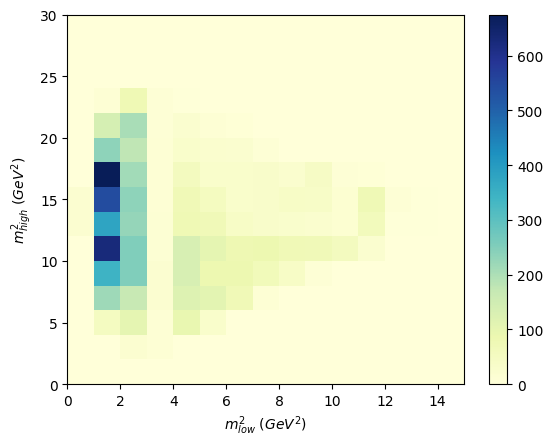

In [ ]:
# Gráfico de Dalitz para los eventos B+
hBp, xbins, ybins, _ = plt.hist2d(R0low/1E6,R0high/1E6,[15,15],[[0,15],[0,30]],cmap='YlGnBu')
plt.colorbar()
plt.xlabel(r'$m_{low}^2$ ($GeV^2$)')
plt.ylabel(r'$m_{high}^2$ ($GeV^2$)')

Text(0, 0.5, '$m_{high}^2$ ($GeV^2$)')

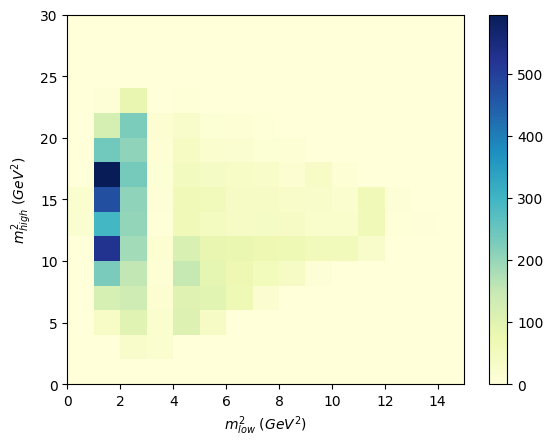

In [ ]:
# Gráfico de Dalitz para los eventos B-
Bm_real_data = real_data.query('B_Charge == -1')
R0low = Bm_real_data[['R02_m2','R03_m2']].min(axis=1)
R0high = Bm_real_data[['R02_m2','R03_m2']].max(axis=1)
hBm, xbins, ybins, _ = plt.hist2d(R0low/1E6,R0high/1E6,[15,15],[[0,15],[0,30]],cmap='YlGnBu')
plt.colorbar()
plt.xlabel(r'$m_{low}^2$ ($GeV^2$)')
plt.ylabel(r'$m_{high}^2$ ($GeV^2$)')

Text(0.5, 1.0, '$A$')

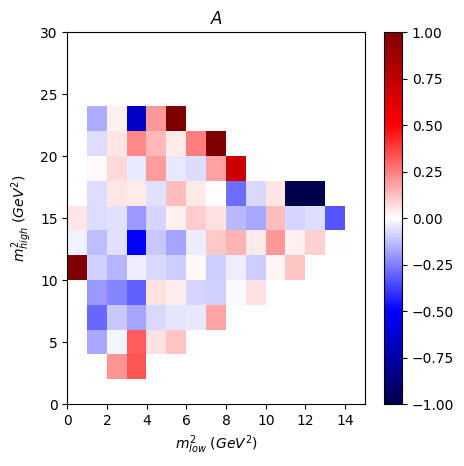

In [ ]:
# Gráfico que muestra la asimetría entre los dos gráficos de Dalitz; es decir, se calcula
# la asimetría entre cada bin de los gráficos de Dalitz B+ y B- y se muestra el resultado en la gráfica 2D
A = (hBm-hBp)/(hBm+hBp)
plt.matshow(A.transpose(), extent=[xbins[0], xbins[-1], ybins[0], ybins[-1]], aspect='auto', origin='lower',cmap='seismic')
plt.gca().xaxis.set_ticks_position('bottom')
plt.colorbar()
plt.xlabel(r'$m_{low}^2$ ($GeV^2$)')
plt.ylabel(r'$m_{high}^2$ ($GeV^2$)')
plt.title(r'$A$')

Observar una gran asimetría en algunas regiones del gráfico no significa necesariamente que hayas observado violación CP. Si hay muy pocos eventos en esa región del gráfico, la incertidumbre sobre esa gran asimetría puede ser grande. Por lo tanto, el valor podría ser aún compatible con cero.

Puedes calcular la incertidumbre estadística de la asimetría, para cada intervalo del gráfico, usando las mismas fórmulas que usaste en la sección de asimetría global. Luego puedes hacer un gráfico que muestre la incertidumbre sobre la asimetría.

Dividiendo el gráfico que muestra la asimetría por el gráfico que muestra la incertidumbre estadística, puedes obtener la significancia de la asimetría en cada intervalo. Luego puedes trazar la significancia de la asimetría para ver si hay alguna evidencia de violación CP.

Text(0.5, 1.0, '$\\sigma_A$')

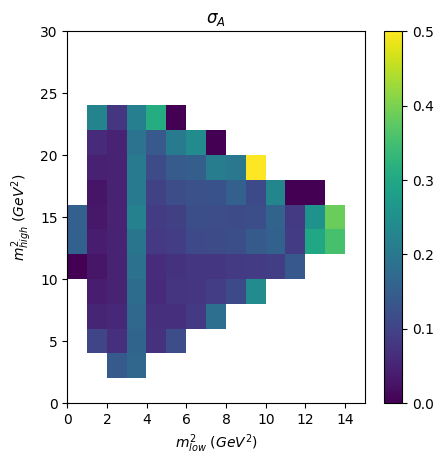

In [ ]:
# Gráfico que muestra la incertidumbre en la asimetría
sigma_A = numpy.sqrt((1-A**2)/(hBm+hBp))
plt.matshow(sigma_A.transpose(), extent=[xbins[0], xbins[-1], ybins[0], ybins[-1]], aspect='auto', origin='lower')
plt.gca().xaxis.set_ticks_position('bottom')
plt.colorbar()
plt.xlabel(r'$m_{low}^2$ ($GeV^2$)')
plt.ylabel(r'$m_{high}^2$ ($GeV^2$)')
plt.title(r'$\sigma_A$')

Text(0.5, 1.0, '$A/\\sigma_A$')

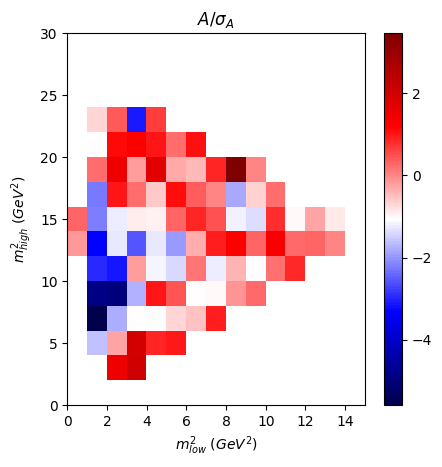

In [ ]:
# Gráfico que muestra la significancia estadística de la asimetría
significance = A/sigma_A
plt.matshow(significance.transpose(), extent=[xbins[0], xbins[-1], ybins[0], ybins[-1]], aspect='auto', origin='lower',cmap='seismic')
plt.gca().xaxis.set_ticks_position('bottom')
plt.colorbar()
plt.xlabel(r'$m_{low}^2$ ($GeV^2$)')
plt.ylabel(r'$m_{high}^2$ ($GeV^2$)')
plt.title(r'$A/\sigma_A$')

## Observando violación CP
A partir de tus estudios del gráfico de asimetría y del gráfico de su significancia, podrás identificar regiones en los diagramas de Dalitz que muestren indicios de violación CP considerable y significativa. Puede que encuentres varios intervalos consecutivos con asimetrías significativas positivas o negativas. Es posible que desees probar diferentes intervalos (binnings) de los diagramas de Dalitz para aislar mejor las regiones en las que ocurren las asimetrías significativas.

Puedes seleccionar eventos que estén en estas regiones de los diagramas de Dalitz donde observes signos de violación CP. Luego puedes trazar un histograma 1D simple de la distribución de masa invariante de los eventos B<sup>+</sup> y B<sup>-</sup>, tal como hiciste al comienzo del proyecto, pero solo para eventos que se encuentren en la región del diagrama de Dalitz que te interesa. Haz los gráficos de los eventos B<sup>+</sup> y B<sup>-</sup> con la misma escala, o superpón los dos gráficos, para que puedas observar si los procesos de desintegración de partícula y antipartícula ocurren a la misma tasa.

Text(0, 0.5, 'Number of events')

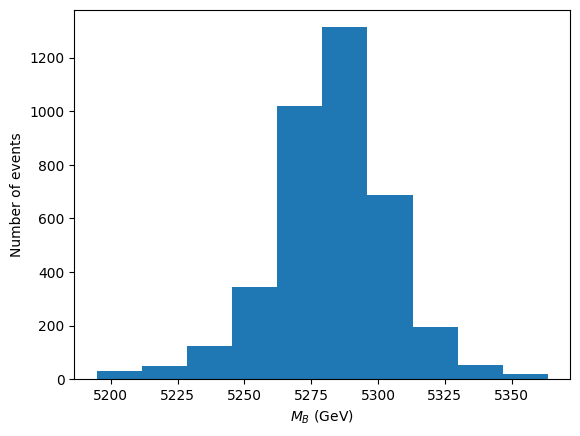

In [ ]:
# Gráfico que muestra la masa invariante de las partículas del mesón B+ utilizando 
# eventos de una región del diagrama de Dalitz que muestra asimetrías CP considerables
real_data_largeCPV = real_data.query('((R02_m2<R03_m2) & ( (R02_m2>1E6) & (R02_m2<2E6) & (R03_m2<16E6))) | ((R02_m2>R03_m2) & ( (R03_m2>1E6) & (R03_m2<2E6) & (R02_m2<16E6)))')
plt.hist(real_data_largeCPV['B_M'])
plt.xlabel(r'$M_B$ (GeV)')
plt.ylabel('Number of events')

Text(0, 0.5, 'Number of events')

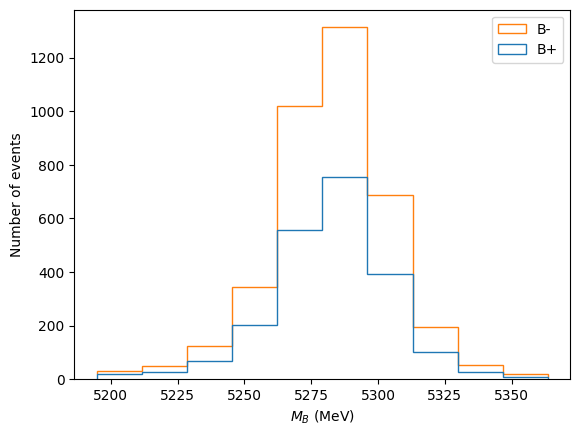

In [ ]:
# Gráfico de la masa invariante de las partículas del mesón B- utilizando eventos de la misma región
plt.hist([real_data_largeCPV.query('B_Charge == 1')['B_M'],real_data_largeCPV.query('B_Charge == -1')['B_M']], histtype='step', stacked=True, fill=False,label=['B+','B-'])
plt.legend()
plt.xlabel(r'$M_B$ (MeV)')
plt.ylabel('Number of events')

**¡Felicitaciones!** Ahora deberías haber observado exitosamente evidencia significativa de violación CP. Deberías tener gráficos que muestren claramente que los procesos de desintegración de partícula y antipartícula ocurren a diferentes tasas en regiones locales del diagrama de Dalitz. Es posible que desees comparar tus resultados con los publicados por la colaboración LHCb en este [artículo](http://lhcbproject.web.cern.ch/lhcbproject/Publications/LHCbProjectPublic/LHCb-PAPER-2013-027.html).

Bien hecho has completado exitosamente tu primer proyecto de análisis de física de partículas. Hay muchos más análisis que se pueden realizar con el conjunto de datos que se te ha proporcionado y las habilidades que has adquirido. En la sección siguiente se exploran ideas para algunos de ellos. ¡Quizás puedas descubrir algo nuevo!

## Añadiendo sofisticación adicional
### Ajustando la masa
Hasta ahora solo has usado el número total de eventos para calcular la asimetría. Sin embargo, tu histograma de masa invariante es una combinación de señal sobre fondo. Para extraer el número correcto de candidatos a señal, tienes que usar una función para ajustar tu señal y tu fondo.

### Hint - Desafíos 3 y 4
Algunas funciones típicas para la señal son la función gaussiana o la función Crystal Ball. Para el fondo, se utilizan comúnmente la función exponencial o un polinomio.

In [81]:
fit_data = real_data.copy()
mkaon = 493.677 # MeV/c^2
for hadron in ("H1", "H2", "H3"):
    momentum_squared = (
        fit_data[f"{hadron}_PX"]**2 + fit_data[f"{hadron}_PY"]**2 + fit_data[f"{hadron}_PZ"]**2
    )
    fit_data[f"{hadron}_E_fit"] = numpy.sqrt(momentum_squared + mkaon**2)

fit_data["B_E_fit"] = (fit_data["H1_E_fit"] + fit_data["H2_E_fit"] + fit_data["H3_E_fit"])
fit_data["B_PX_fit"] = (fit_data["H1_PX"] + fit_data["H2_PX"] + fit_data["H3_PX"])
fit_data["B_PY_fit"] = (fit_data["H1_PY"] + fit_data["H2_PY"] + fit_data["H3_PY"])
fit_data["B_PZ_fit"] = (fit_data["H1_PZ"] + fit_data["H2_PZ"] + fit_data["H3_PZ"])
fit_data["B_M2_fit"] = (fit_data["B_E_fit"]**2 - fit_data["B_PX_fit"]**2 - fit_data["B_PY_fit"]**2 - fit_data["B_PZ_fit"]**2)
fit_data["B_M_fit"] = numpy.sqrt(numpy.clip(fit_data["B_M2_fit"], a_min=0, a_max=None))

if "B_Charge" not in fit_data.columns:
    fit_data["B_Charge"] = (fit_data["H1_Charge"] + fit_data["H2_Charge"] + fit_data["H3_Charge"])

MASS_MIN = 5100.0
MASS_MAX = 5500.0
N_BINS = 80

BIN_WIDTH = (MASS_MAX - MASS_MIN) / N_BINS
MASS_CENTER = (MASS_MIN + MASS_MAX) / 2.0

# Primer modelo (señal Gaussianna + fondo exponencial)
def exponential_PDF(x, slope):
    lower = MASS_MIN - MASS_CENTER
    upper = MASS_MAX - MASS_CENTER
    if abs(slope) < 1e-10:
        return numpy.ones_like(x) / (MASS_MAX - MASS_MIN)
    norm = (numpy.exp(slope * upper) - numpy.exp(slope * lower)) / slope
    return (numpy.exp(slope * (x - MASS_CENTER))/norm)

def nominal_model(x, n_signal, mean, sigma, n_background, slope):
    signal_pdf = stats.norm.pdf(x, loc=mean, scale=sigma)
    background_pdf = exponential_PDF(x, slope)
    return BIN_WIDTH * (n_signal * signal_pdf + n_background * background_pdf)

# Segundo modelo (Crustal Ball + fondo lineal)
def cb_pdf(x, beta, m, mean, sigma):
    norm = (stats.crystalball.cdf(MASS_MAX, beta, m, loc=mean, scale=sigma)) - (stats.crystalball.cdf(MASS_MIN, beta, m, loc=mean, scale=sigma))
    return (stats.crystalball.pdf(x, beta, m, loc=mean, scale=sigma) / norm)

def linear_pdf(x, slope):
    scaled_x = (x-MASS_CENTER)/(0.5*(MASS_MAX-MASS_MIN))
    return (1.0 + slope * scaled_x) / (MASS_MAX - MASS_MIN)

def alternative_model(x, n_signal, beta, m, mean, sigma, n_background, slope):
    sifnal_pdf = cb_pdf(x, beta, m, mean, sigma)
    background_pdf = linear_pdf(x, slope)
    return BIN_WIDTH * (n_signal * sifnal_pdf + n_background * background_pdf)

# Ajuste de muestra
def fit_mass_sample(masses, model_name):
    masses = numpy.asarray(masses, dtype=numpy.float64)
    masses = masses[numpy.isfinite(masses) & (masses >= MASS_MIN) & (masses <= MASS_MAX)]
    counts, bin_edges = numpy.histogram(masses, bins=N_BINS, range=(MASS_MIN, MASS_MAX))
    bin_centers = (bin_edges[:-1]+bin_edges[1:])/2.0

    # Incertidumbre de Poisson aproximada
    uncert = numpy.sqrt(numpy.maximum(counts, 1.0))
    total_events = counts.sum()
    if total_events == 0:
        raise ValueError("No hay eventos dentro del intervalo de ajuste.")
    if model_name == "nominal":
        model = nominal_model
        i_params = [
            0.65 * total_events,  # señal
            5279.0,               # media
            18.0,                 # sigma
            0.35 * total_events,  # fondo
            -0.002                # pendiente del fondo
        ]
        lower_bounds = [0.0, 5240.0, 3.0, 0.0, -0.02]
        upper_bounds = [1.5*total_events, 5320.0, 60.0, 1.5*total_events, 0.02]
    elif model_name == "alternative":
        model = alternative_model
        i_params = [
            0.65 * total_events,  # señal
            2.0,                  # beta crystal ball
            3.0,                  # m crystal ball
            5279.0,               # media
            18.0,                 # sigma
            0.35 * total_events,  # fondo
            0.0                   # pendiente lineal del fondo
        ]
        lower_bounds = [0.0, 0.3, 1.01, 5240.0, 3.0, 0.0, -0.95]
        upper_bounds = [1.5*total_events, 15.0, 30.0, 5320.0, 60.0, 1.5*total_events, 0.95]
    else: 
        raise ValueError("Modelo desconocido. Use 'nominal' o 'alternative'.")
    parameters, covariance = cf(
        model,
        bin_centers,
        counts,
        p0=i_params,
        sigma=uncert,
        absolute_sigma=True,
        bounds=(lower_bounds, upper_bounds),
        maxfev=200000
    )
    expected_counts = model(bin_centers, *parameters)
    chi_squared = numpy.sum(((counts - expected_counts)/uncert)**2)
    degrees_of_freedom = (len(counts)-len(parameters))
    return {
        "model_name": model_name,
        "model": model,
        "parameters": parameters,
        "covariance": covariance,
        "counts": counts,
        "edges": bin_edges,
        "centers": bin_centers,
        "uncertainties": uncert,
        "n_signal": parameters[0],
        "n_signal_error": numpy.sqrt(numpy.clip(covariance[0,0], a_min=0.0, a_max=None)),
        "chi2": chi_squared,
        "ndf": degrees_of_freedom
    }

# Componentes
def fit_componentes(x, fit_result):
    parameters = fit_result["parameters"]
    if fit_result["model_name"] == "nominal":
        (n_signal, mean, sigma, n_background, slope) = parameters
        signal = (BIN_WIDTH*n_signal*stats.norm.pdf(x, loc=mean, scale=sigma))
        background = (BIN_WIDTH*n_background*exponential_PDF(x, slope))
    else:
        (n_signal, beta, m, mean, sigma, n_background, slope) = parameters
        signal = (BIN_WIDTH*n_signal*cb_pdf(x, beta, m, mean, sigma))
        background = (BIN_WIDTH*n_background*linear_pdf(x, slope))
    return signal, background

def plot_fit_result(fit_r, title):
    x_dense = numpy.linspace(MASS_MIN, MASS_MAX, 1000)
    total_fit = fit_r["model"](x_dense, *fit_r["parameters"])
    signal, background = fit_componentes(x_dense, fit_r)
    plt.figure(figsize=(10, 6))
    plt.errorbar(
        fit_r["centers"],
        fit_r["counts"],
        yerr=fit_r["uncertainties"],
        fmt="o",
        markersize=3,
        label="Datos"
    )
    plt.plot(x_dense, total_fit, label="Ajuste total")
    plt.plot(x_dense, signal, linestyle="--", label="Señal")
    plt.plot(x_dense, background, linestyle=":", label="Fondo")
    plt.xlabel(r"$m(KKK)$ [MeV/$c^2$]")
    plt.ylabel(f"Events/{BIN_WIDTH:.1f} [MeV]")
    plt.title(title)
    plt.legend()
    plt.show()

# Asimetría y propagación de incertidumbre
def asymetry(fit_r):
    n_minus = fit_r[-1]["n_signal"]
    n_plus = fit_r[1]["n_signal"]
    error_minus = (fit_r[-1]["n_signal_error"])
    error_plus = (fit_r[1]["n_signal_error"])
    den = n_minus + n_plus
    asym = (n_minus - n_plus)/den
    derivative_minus = (2.0*n_plus / den**2)
    derivative_plus = (2.0*n_minus / den**2)
    uncertaintly = numpy.sqrt((derivative_minus*error_minus)**2 + (derivative_plus*error_plus)**2)
    return {
        "N_minus": n_minus,
        "N_plus": n_plus,
        "error_minus": error_minus,
        "error_plus": error_plus,
        "asymmetry": asym,
        "uncertainty": uncertaintly
    }

print("Eventos disponibles para el ajuste:", len(fit_data))
print("Intervalo de ajuste:", MASS_MIN, "a", MASS_MAX, "[MeV/$c^2$]")

Eventos disponibles para el ajuste: 15024
Intervalo de ajuste: 5100.0 a 5500.0 [MeV/$c^2$]


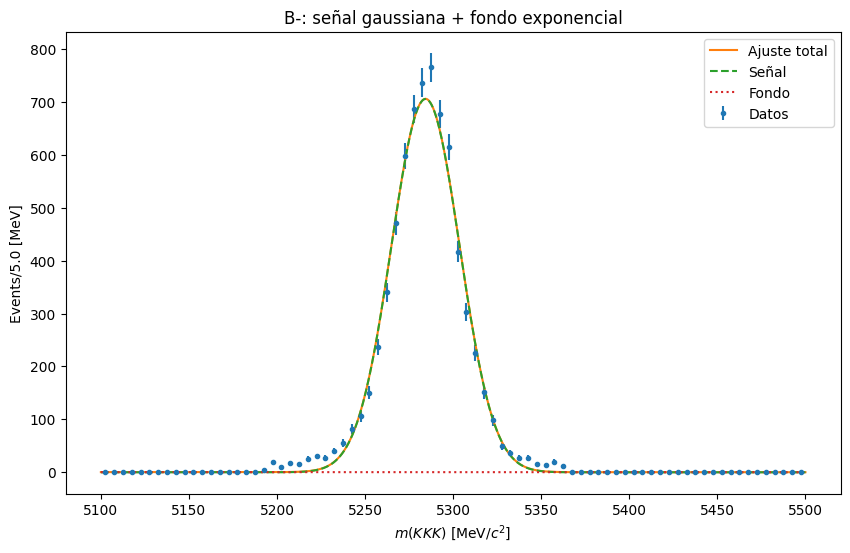

B-: N_señal = 6844 ± 83
B-: Chi2/ndf = 247.5/75



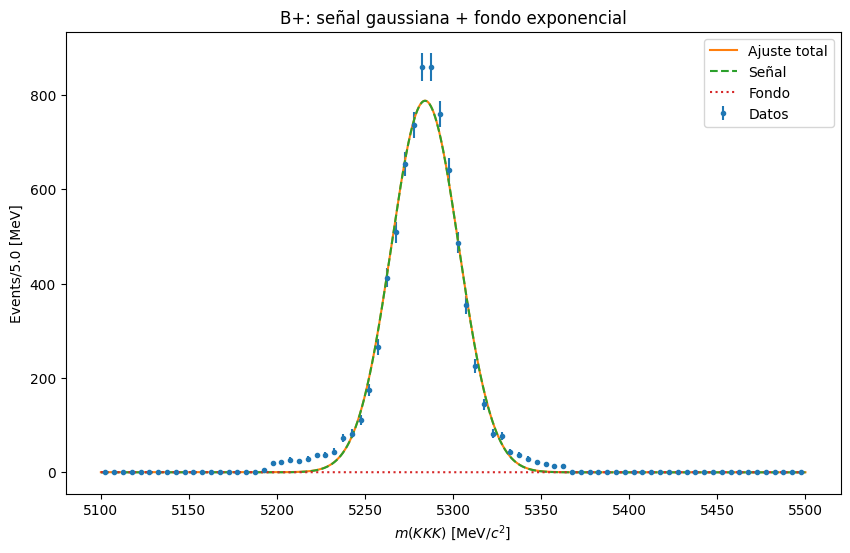

B+: N_señal = 7585 ± 87
B+: Chi2/ndf = 328.2/75



In [ ]:
# Gráfica y ajuste de la masa invariante del mesón B-
nominal_fits = {}
for charge, label in [(-1, "B-"), (1, "B+")]:
    mass = fit_data.loc[fit_data["B_Charge"] == charge, "B_M_fit"]
    result = fit_mass_sample(mass, model_name="nominal")
    nominal_fits[charge] = result
    plot_fit_result(result, (f"{label}: señal gaussiana + fondo exponencial"))
    print(f"{label}: " f"N_señal = " f"{result['n_signal']:.0f} ± " f"{result['n_signal_error']:.0f}")
    print(f"{label}: "f"Chi2/ndf = "f"{result['chi2']:.1f}/"f"{result['ndf']}")
    print()

In [ ]:
# Cálculo de la asimetría CP usando los valores extraidos del ajuste
nominal_asymetry = asymetry(nominal_fits)
print("N- = " f"{nominal_asymetry['N_minus']:.0f} ± " f"{nominal_asymetry['error_minus']:.0f}")
print("N+ = " f"{nominal_asymetry['N_plus']:.0f} ± " f"{nominal_asymetry['error_plus']:.0f}")
print("A_CP nominal = " f"{nominal_asymetry['asymmetry']:.6f} ± " f"{nominal_asymetry['uncertainty']:.6f}")
nominal_significance = (nominal_asymetry["asymmetry"]/nominal_asymetry["uncertainty"])
print("Significancia nominal =" f"{nominal_significance:.2f} $\sigma$")

N- = 6844 ± 83
N+ = 7585 ± 87
A_CP nominal = -0.051352 ± 0.008325
Significancia nominal =-6.17 $\sigma$


### Incertidumbres sistemáticas - Desafío 4
En este análisis consideraste la incertidumbre estadística sobre el resultado. Esta ocurre como resultado de tener solo un número limitado de eventos. Además, existen [incertidumbres sistemáticas](https://en.wikipedia.org/wiki/Observational_error#Systematic_versus_random_error), que surgen de sesgos en tu medición.

En esta sección calcularás las incertidumbres sistemáticas de usar diferentes modelos/funciones para ajustar tu señal y tu fondo. Intenta usar una función diferente para tu señal (por ejemplo, en lugar de una gaussiana usa una Crystal Ball) y calcula la asimetría al usar esta otra función. Haz lo mismo para la función de fondo.

La incertidumbre sistemática será la diferencia entre los dos valores de la asimetría.

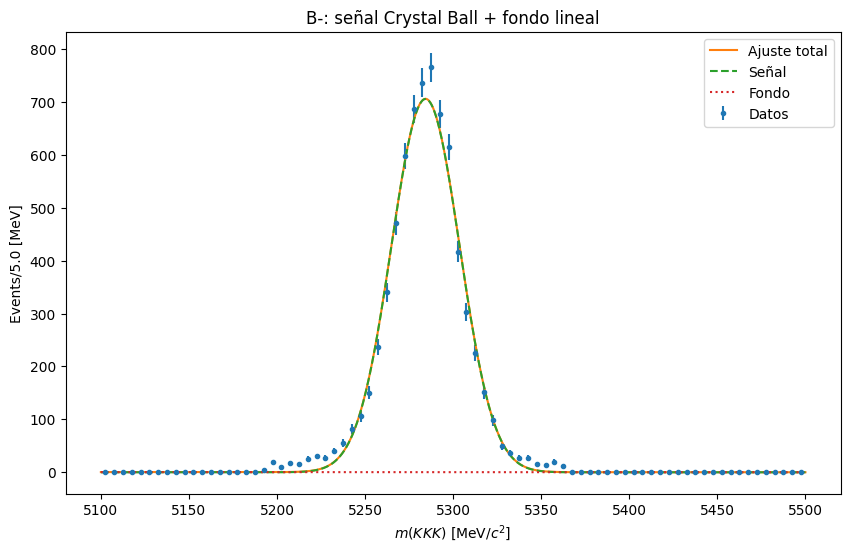

B-: N_señal = 6843 ± 83
B-: chi2/ndf = 247.3 / 73



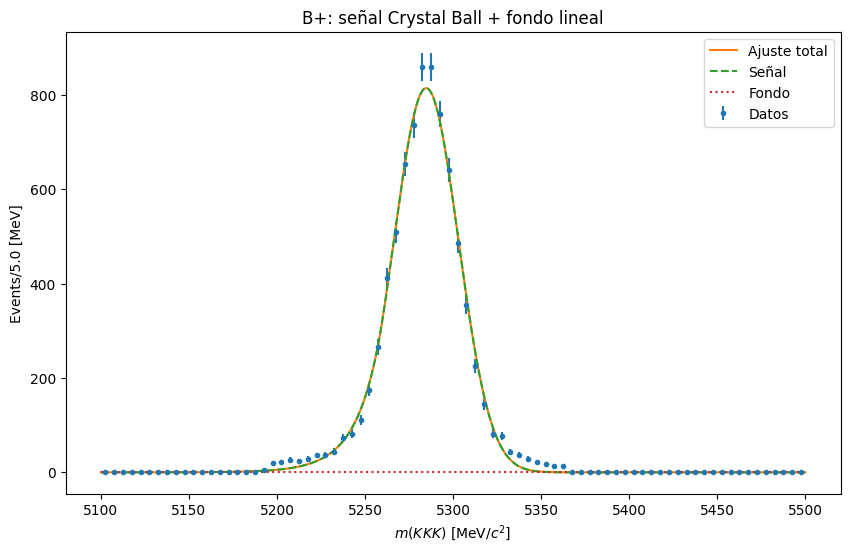

B+: N_señal = 7732 ± 89
B+: chi2/ndf = 198.3 / 73



In [ ]:
# Gráfica y ajuste de la masa invariante del mesón B- usando otra función de ajuste
alternative_fits = {}
for charge, label in [(-1, "B-"), (1, "B+")]:
    mass = fit_data.loc[fit_data["B_Charge"] == charge, "B_M_fit"]
    result = fit_mass_sample(mass, model_name="alternative")
    alternative_fits[charge] = result
    plot_fit_result(result, (f"{label}: señal Crystal Ball + fondo lineal"))
    print(f"{label}: " f"N_señal = " f"{result['n_signal']:.0f} ± " f"{result['n_signal_error']:.0f}")
    print(f"{label}: " f"chi2/ndf = " f"{result['chi2']:.1f} / " f"{result['ndf']}")
    print()

In [ ]:
# Cálculo de la asimetría CP usando los valores extraídos del ajuste
alternative_asymmetry = asymetry(alternative_fits)
print("N- alternativo = " f"{alternative_asymmetry['N_minus']:.0f} ±" f"{alternative_asymmetry['error_minus']:.0f}")
print("N+ alternativo = " f"{alternative_asymmetry['N_plus']:.0f} ±" f"{alternative_asymmetry['error_plus']:.0f}")
print("A_CP alternativo = "f"{alternative_asymmetry['asymmetry']:.6f} ± "f"{alternative_asymmetry['uncertainty']}")
alternative_significance = (alternative_asymmetry["asymmetry"]/alternative_asymmetry["uncertainty"])
print("Significancia alternativa = "f"{alternative_significance:.2f} σ")

N- alternativo = 6843 ±83
N+ alternativo = 7732 ±89
A_CP alternativo = -0.060984 ± 0.00830280684014718
Significancia alternativa = -7.34 σ


In [ ]:
# Cálculo de la incertidumbre sistemática
systematic_uncertainty = abs(alternative_asymmetry["asymmetry"]-nominal_asymetry["asymmetry"])
total_uncertainty = numpy.sqrt(nominal_asymetry["uncertainty"]**2 + systematic_uncertainty**2)
print("A_CP nominal = "f"{nominal_asymetry['asymmetry']:.6f}")
print("A_CP alternativo = "f"{alternative_asymmetry['asymmetry']:.6f}")
print("Incertidumbre estadística = "f"{nominal_asymetry['uncertainty']:.6f}")
print("Incertidumbre sistemática por modelo = "f"{systematic_uncertainty:.6f}")
print("Incertidumbre total = "f"{total_uncertainty:.6f}")
print("\nResultado:")
print(
    "A_CP = "
    f"{nominal_asymetry['asymmetry']:.6f}"
    f"± {nominal_asymetry['uncertainty']:.6f}"
    f"(estadística )"
    f"± {systematic_uncertainty:.6f}"
    f"(sistemática)"
)

A_CP nominal = -0.051352
A_CP alternativo = -0.060984
Incertidumbre estadística = 0.008325
Incertidumbre sistemática por modelo = 0.009632
Incertidumbre total = 0.012731

Resultado:
A_CP = -0.051352± 0.008325(estadística )± 0.009632(sistemática)


# Análisis adicionales

El conjunto de datos que se te ha proporcionado es el conjunto completo de datos registrados por LHCb preseleccionados para desintegraciones de mesones B cargados en tres trayectorias en el estado final. Este conjunto de datos se ha utilizado para dos publicaciones importantes, [aquí](http://lhcbproject.web.cern.ch/lhcbproject/Publications/LHCbProjectPublic/LHCb-PAPER-2013-027.html) y [aquí](http://lhcbproject.web.cern.ch/lhcbproject/Publications/LHCbProjectPublic/LHCb-PAPER-2013-051.html).

Discutimos aquí:

<ul> <li>Elementos adicionales que podrías añadir a tu análisis de B<sup>+</sup> → K<sup>+</sup>K<sup>+</sup>K<sup>−</sup></li> <li>Análisis adicionales que podrías realizar con este conjunto de datos</li> </ul>

### Más incertidumbres sistemáticas
En este análisis consideraste la incertidumbre estadística sobre el resultado. Esta ocurre como resultado de tener solo un número limitado de eventos. Además, existen [incertidumbres sistemáticas](https://en.wikipedia.org/wiki/Observational_error#Systematic_versus_random_error), que surgen de sesgos en tu medición. Aquí discutimos tres fuentes de estas para este análisis.

<ul> <li> Asimetría de producción. El LHC es un colisionador protón-protón y por lo tanto el estado inicial de la colisión no es simétrico en materia-antimateria. En consecuencia, los mesones B<sup>+</sup> y B<sup>-</sup> pueden no producirse exactamente a las mismas tasas. Se estima que esta pequeña asimetría de producción podría ser aproximadamente del 1%. También se puede medir a partir de los datos, como se discute en el artículo de LHCb.</li> <li> Asimetría de detección. El detector LHCb podría ser más eficiente para detectar los estados finales de B<sup>+</sup> o de B<sup>-</sup>. Esto se debe a que los kaones positivos y negativos serán desviados por el imán en direcciones diferentes en el detector. Si la eficiencia del detector es mayor en una región que en otra, esto conducirá a mayores eficiencias para K<sup>+</sup> o K<sup>-</sup> y por lo tanto para B<sup>+</sup> o B<sup>-</sup>. Por esta razón, el campo magnético del detector LHCb se invierte regularmente. En este análisis utilizaste datos en los que el campo magnético estaba tanto hacia arriba como hacia abajo, por lo que el efecto se cancelará (parcialmente). Comparando los resultados por separado para las dos polaridades del imán, puedes verificar el tamaño de este efecto. Al cargar los datos anteriormente, ambas polaridades se combinaron; puedes cargarlos de forma independiente para medir la diferencia entre los dos conjuntos de datos.</li> <li> Técnica de análisis. La técnica de análisis que has utilizado puede sesgar el resultado. Una simplificación importante que hicimos en el análisis anterior fue descuidar los eventos de 'fondo'. Impusimos una selección para elegir una muestra de eventos predominantemente de señal, pero no hemos tenido en cuenta el efecto de los eventos de fondo residuales.</li> </ul>

### Usando bandas laterales de masa
Una fuente de eventos de 'fondo' surge de combinaciones aleatorias de trayectorias en eventos que logran falsificar las características de la 'señal'. Estos eventos no tendrán un pico en la distribución de masa en la masa del mesón B, sino que tendrán una distribución que varía suavemente. Observar el número y la distribución de eventos lejos del pico de masa puede permitirte estimar el número de eventos de fondo debajo del pico de masa.

### Ajustando distribuciones
El siguiente nivel de sofisticación en el análisis requiere ajustar las distribuciones de eventos que se observan en la distribución de masa del B para estimar el rendimiento de eventos de señal y eventos de fondo. Puedes ver cómo se hace esto en el artículo de LHCb sobre el análisis. El ajuste se puede realizar utilizando el [marco de trabajo root del CERN](https://root.cern.ch/).

## Análisis adicionales
Los artículos de LHCb que utilizan este conjunto de datos que estás utilizando analizaron cuatro canales de desintegración de los mesones B cargados. Puedes realizar cualquiera de estos análisis.

<ul> <li>B<sup>+</sup> → K<sup>+</sup>K<sup>+</sup>K<sup>−</sup> (y su equivalente de antipartícula). Este es el análisis que has realizado aquí. Tiene el fondo más bajo de los cuatro canales, por lo que la aproximación que hicimos de despreciar los eventos de fondo dará el menor sesgo a este canal.</li> <li>B<sup>+</sup> → π<sup>+</sup>π<sup>+</sup>π<sup>−</sup> (y su equivalente de antipartícula). En este análisis, el estado final son tres piones cargados. El nivel de eventos de fondo en comparación con la señal es significativamente mayor, ya que los piones son las partículas más comúnmente producidas en el LHC. Por lo tanto, se debe añadir un método para estimar el nivel de fondo para completar este análisis.</li> <li>B<sup>+</sup> → K<sup>+</sup>π<sup>+</sup>π<sup>−</sup> (y su equivalente de antipartícula). En este análisis, el estado final es una mezcla de un kaón y dos piones. Esto significa que el análisis necesita determinar en cada evento qué trayectoria es el mejor candidato a kaón y aplicar cortes de selección apropiadamente para seleccionar los eventos.</li> <li>B<sup>+</sup> → π<sup>+</sup>K<sup>+</sup>K<sup>−</sup> (y su equivalente de antipartícula). Este canal tiene un nivel de fondo más alto en comparación con la señal.</li> </ul>